In [1]:
# Import required libraries
import os
import json
import pickle
import numpy as np
import pandas as pd
import yfinance as yf
import talib as tal
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Try to import TensorFlow/Keras for neural network models
try:
    import tensorflow as tf
    from tensorflow import keras
    KERAS_AVAILABLE = True
    print("✅ TensorFlow/Keras available")
except ImportError:
    KERAS_AVAILABLE = False
    print("⚠️ TensorFlow/Keras not available - only sklearn models supported")

print("✅ Libraries imported successfully")

✅ TensorFlow/Keras available
✅ Libraries imported successfully


In [2]:
# ---- Ensure `data_by_timeframe` exists (fallback auto-discovery)
import pandas as pd
import numpy as np
if 'data_by_timeframe' not in globals() or not isinstance(data_by_timeframe, dict):
    data_by_timeframe = {}
    # Discover any DF_... DataFrames (raw or processed) in globals()
    for name, val in list(globals().items()):
        if name.startswith('DF_') and isinstance(val, pd.DataFrame):
            tf = name.replace('DF_','').lower().split('_')[0]
            data_by_timeframe[tf] = val.copy()
    # Also consider DF_PROCESSED_* variables
    if not data_by_timeframe:
        for name, val in list(globals().items()):
            if name.startswith('DF_PROCESSED_') and isinstance(val, pd.DataFrame):
                tf = name.replace('DF_PROCESSED_','').lower()
                data_by_timeframe[tf] = val.copy()
    # As a last resort, try X_<tf> feature matrices
    if not data_by_timeframe:
        for name, val in list(globals().items()):
            if name.startswith('X_') and isinstance(val, pd.DataFrame):
                tf = name.replace('X_','').lower()
                data_by_timeframe[tf] = val.copy()
    if data_by_timeframe:
        print('✅ Auto-discovered data_by_timeframe for:', list(data_by_timeframe.keys()))
    else:
        print('⚠️ data_by_timeframe not found and no DF_/DF_PROCESSED_/X_ variables detected.')
        print('   Please run the data loading cells to populate `data_by_timeframe` before continuing.')

⚠️ data_by_timeframe not found and no DF_/DF_PROCESSED_/X_ variables detected.
   Please run the data loading cells to populate `data_by_timeframe` before continuing.


## 1️⃣ Load Model Information from Results Folder

In [3]:
# Path to the results folder
RESULTS_PATH = r"C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_30m_20260117_125759"

# Load config (contains symbol, timeframe, etc.)
with open(f"{RESULTS_PATH}/config.json", "r") as f:
    config = json.load(f)

# Optional: load structured models registry (newer `test.py` runs)
REGISTRY_PATH = f"{RESULTS_PATH}/models_registry.json"
models_registry = None
if os.path.exists(REGISTRY_PATH):
    try:
        with open(REGISTRY_PATH, "r") as f:
            models_registry = json.load(f)
        print(f"✅ Models registry loaded from: {REGISTRY_PATH}")
    except Exception as e:
        models_registry = None
        print(f"⚠️ Failed to read models_registry.json: {e}")
else:
    print("ℹ️ models_registry.json not found (older run) — falling back to results_summary.json")

# Load results summary (contains best model name and accuracy)
with open(f"{RESULTS_PATH}/results_summary.json", "r") as f:
    results = json.load(f)

# Load feature columns (if available)
FEATURES_PATH = f"{RESULTS_PATH}/features.json"
try:
    with open(FEATURES_PATH, "r") as f:
        features_config = json.load(f)
    FEATURE_COLUMNS_LOADED = True
    print(f"✅ Feature columns loaded from: {FEATURES_PATH}")
except FileNotFoundError:
    features_config = None
    FEATURE_COLUMNS_LOADED = False
    print(f"⚠️ features.json not found - will extract features from model")

# Extract key information
SYMBOL = config['symbol']
TIMEFRAME = config['timeframe']

# Get ranking from results_summary
ranking = results.get('ranking', [])
all_models_info = results.get('all_models', {})

# ============================================================================
# AUTOMATICALLY LOAD THE BEST MODEL (.keras or .pkl)
# ============================================================================
print("\n" + "=" * 70)
print("🏆 LOADING BEST MODEL AUTOMATICALLY")
print("=" * 70)

BEST_MODEL_NAME = results.get('best_model')
if not BEST_MODEL_NAME:
    raise ValueError("❌ No best_model found in results_summary.json!")

print(f"\n🎯 Best model from results: {BEST_MODEL_NAME}")

# Check for model file (.keras or .pkl)
models_dir = os.path.join(RESULTS_PATH, "models")
SELECTED_MODEL_PATH = None
SELECTED_MODEL_TYPE = None

# Priority: check models/ subdirectory first, then root
search_paths = []
if os.path.exists(models_dir):
    search_paths.append((models_dir, f"{BEST_MODEL_NAME}.keras"))
    search_paths.append((models_dir, f"{BEST_MODEL_NAME}.pkl"))
search_paths.append((RESULTS_PATH, f"{BEST_MODEL_NAME}.keras"))
search_paths.append((RESULTS_PATH, f"{BEST_MODEL_NAME}.pkl"))
search_paths.append((RESULTS_PATH, "best_model.keras"))
search_paths.append((RESULTS_PATH, "best_model.pkl"))

for folder, filename in search_paths:
    full_path = os.path.join(folder, filename)
    if os.path.exists(full_path):
        SELECTED_MODEL_PATH = full_path
        SELECTED_MODEL_TYPE = 'keras' if filename.endswith('.keras') else 'pkl'
        break

if SELECTED_MODEL_PATH is None:
    raise FileNotFoundError(f"❌ No model file found for best model: {BEST_MODEL_NAME}")

print(f"   ✅ Found: {SELECTED_MODEL_PATH}")

# Get model info from ranking
SELECTED_MODEL_NAME = BEST_MODEL_NAME
best_model_info = next((item for item in ranking if item['model'] == BEST_MODEL_NAME), None)

if best_model_info:
    SELECTED_FEATURE_SET = best_model_info.get('feature_set', 'X')
    TRAIN_ACCURACY = best_model_info.get('train_acc', 0)
    FORWARD_ACCURACY = best_model_info.get('forward_acc', 0)
else:
    SELECTED_FEATURE_SET = 'X'
    TRAIN_ACCURACY = 0
    FORWARD_ACCURACY = 0

# Try to get more details from models_registry
SELECTED_MODEL_CLASS = None
if models_registry is not None:
    model_entry = (models_registry.get('models', {}) or {}).get(SELECTED_MODEL_NAME, {})
    SELECTED_MODEL_CLASS = model_entry.get('model_class')
    # Update type from registry if available
    registry_type = model_entry.get('type')
    if registry_type in ['keras', 'sklearn', 'pkl']:
        SELECTED_MODEL_TYPE = registry_type

print("\n" + "=" * 70)
print("📊 BEST MODEL INFORMATION")
print("=" * 70)
print(f"Symbol:           {SYMBOL}")
print(f"Timeframe:        {TIMEFRAME}")
print(f"Best Model:       {SELECTED_MODEL_NAME}")
if SELECTED_MODEL_CLASS:
    print(f"Model Class:      {SELECTED_MODEL_CLASS}")
print(f"Model Type:       {SELECTED_MODEL_TYPE}")
print(f"Feature Set:      {SELECTED_FEATURE_SET}")
print(f"Train Accuracy:   {TRAIN_ACCURACY:.4f} ({TRAIN_ACCURACY*100:.2f}%)")
print(f"Forward Accuracy: {FORWARD_ACCURACY:.4f} ({FORWARD_ACCURACY*100:.2f}%)")
print(f"Model File:       {SELECTED_MODEL_PATH}")

# Determine trained features based on feature set
feature_set = SELECTED_FEATURE_SET
trained_features = None
if FEATURE_COLUMNS_LOADED:
    if feature_set == 'X':
        trained_features = features_config.get('X_features', [])
    else:
        trained_features = features_config.get('X_full_features', [])
    print(f"Num Features:     {len(trained_features)}")
else:
    print(f"Features:         Will be extracted from model")

# ============================================================================
# LOAD THE MODEL
# ============================================================================
print("\n🔄 Loading model...")
selected_model = None

if SELECTED_MODEL_TYPE in ['pkl', 'sklearn']:
    with open(SELECTED_MODEL_PATH, "rb") as f:
        selected_model = pickle.load(f)
    print(f"✅ Sklearn model loaded successfully: {SELECTED_MODEL_NAME}")
elif SELECTED_MODEL_TYPE == 'keras' and KERAS_AVAILABLE:
    selected_model = keras.models.load_model(SELECTED_MODEL_PATH)
    print(f"✅ Keras model loaded successfully: {SELECTED_MODEL_NAME}")
elif SELECTED_MODEL_TYPE == 'keras' and not KERAS_AVAILABLE:
    raise ImportError("❌ Keras model selected but TensorFlow/Keras is not available.")
else:
    raise ValueError(f"❌ Unknown model type: {SELECTED_MODEL_TYPE}")

if selected_model is None:
    raise ValueError("❌ Model failed to load!")

print("=" * 70)

✅ Models registry loaded from: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_30m_20260117_125759/models_registry.json
✅ Feature columns loaded from: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_30m_20260117_125759/features.json

🏆 LOADING BEST MODEL AUTOMATICALLY

🎯 Best model from results: RandomForest_X
   ✅ Found: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_30m_20260117_125759\models\RandomForest_X.pkl

📊 BEST MODEL INFORMATION
Symbol:           ETH-USD
Timeframe:        30m
Best Model:       RandomForest_X
Model Class:      RandomForestClassifier
Model Type:       sklearn
Feature Set:      X
Train Accuracy:   0.5520 (55.20%)
Forward Accuracy: 0.5251 (52.51%)
Model File:       C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_30m_20260117_125759\models\RandomForest_X.pkl
Num Features:     18

🔄 Loading model...
✅ Sklearn model loa

In [4]:
# Path to the results root folder (contains all timeframes)
RESULTS_ROOT = r"C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results"

def _load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def _find_model_file(results_path, best_model_name):
    models_dir = os.path.join(results_path, "models")
    search_paths = []
    if os.path.exists(models_dir):
        search_paths.append((models_dir, f"{best_model_name}.keras"))
        search_paths.append((models_dir, f"{best_model_name}.pkl"))
    search_paths.append((results_path, f"{best_model_name}.keras"))
    search_paths.append((results_path, f"{best_model_name}.pkl"))
    search_paths.append((results_path, "best_model.keras"))
    search_paths.append((results_path, "best_model.pkl"))

    for folder, filename in search_paths:
        full_path = os.path.join(folder, filename)
        if os.path.exists(full_path):
            model_type = 'keras' if filename.endswith('.keras') else 'pkl'
            return full_path, model_type

    return None, None

def load_best_model_from_results(results_path):
    config_path = os.path.join(results_path, "config.json")
    results_path_summary = os.path.join(results_path, "results_summary.json")

    if not os.path.exists(config_path) or not os.path.exists(results_path_summary):
        return None

    config = _load_json(config_path)
    results = _load_json(results_path_summary)
    models_registry = None
    registry_path = os.path.join(results_path, "models_registry.json")
    if os.path.exists(registry_path):
        try:
            models_registry = _load_json(registry_path)
        except Exception:
            models_registry = None

    features_config = None
    features_path = os.path.join(results_path, "features.json")
    if os.path.exists(features_path):
        try:
            features_config = _load_json(features_path)
        except Exception:
            features_config = None

    best_model_name = results.get('best_model')
    if not best_model_name:
        return None

    model_path, model_type = _find_model_file(results_path, best_model_name)
    if model_path is None:
        return None

    # Load model
    selected_model = None
    if model_type in ['pkl', 'sklearn']:
        with open(model_path, "rb") as f:
            selected_model = pickle.load(f)
    elif model_type == 'keras' and KERAS_AVAILABLE:
        selected_model = keras.models.load_model(model_path)
    elif model_type == 'keras' and not KERAS_AVAILABLE:
        raise ImportError("❌ Keras model selected but TensorFlow/Keras is not available.")
    else:
        raise ValueError(f"❌ Unknown model type: {model_type}")

    ranking = results.get('ranking', [])
    best_model_info = next((item for item in ranking if item['model'] == best_model_name), None)
    feature_set = best_model_info.get('feature_set', 'X') if best_model_info else 'X'
    train_acc = best_model_info.get('train_acc', 0) if best_model_info else 0
    forward_acc = best_model_info.get('forward_acc', 0) if best_model_info else 0

    selected_model_class = None
    if models_registry is not None:
        model_entry = (models_registry.get('models', {}) or {}).get(best_model_name, {})
        selected_model_class = model_entry.get('model_class')
        registry_type = model_entry.get('type')
        if registry_type in ['keras', 'sklearn', 'pkl']:
            model_type = registry_type

    return {
        'results_path': results_path,
        'config': config,
        'results': results,
        'models_registry': models_registry,
        'features_config': features_config,
        'best_model_name': best_model_name,
        'model_path': model_path,
        'model_type': model_type,
        'model_class': selected_model_class,
        'feature_set': feature_set,
        'train_acc': train_acc,
        'forward_acc': forward_acc,
        'ranking': ranking,
        'selected_model': selected_model,
    }

# ============================================================================
# LOAD BEST MODEL FOR EACH TIMEFRAME
# ============================================================================
print("\n" + "=" * 70)
print("🏆 LOADING BEST MODEL FOR EACH TIMEFRAME")
print("=" * 70)

models_by_timeframe = {}
runs_loaded = 0

for run_name in sorted(os.listdir(RESULTS_ROOT)):
    run_path = os.path.join(RESULTS_ROOT, run_name)
    if not os.path.isdir(run_path):
        continue

    try:
        result = load_best_model_from_results(run_path)
    except Exception as e:
        print(f"⚠️ Skipping {run_name}: {e}")
        continue

    if result is None:
        print(f"⚠️ Skipping {run_name}: missing config/results or best model")
        continue

    tf = result['config'].get('timeframe', 'unknown')
    symbol = result['config'].get('symbol', 'unknown')
    models_by_timeframe[tf] = result
    runs_loaded += 1

    print(f"✅ {symbol} {tf}: {result['best_model_name']} ({result['model_type']})")
    print(f"   Path: {result['model_path']}")

if runs_loaded == 0:
    raise RuntimeError("❌ No valid results found in results folder.")

# ---------------------------------------------------------------------------
# Choose a default timeframe to keep the rest of the notebook working
# ---------------------------------------------------------------------------
PREFERRED_TIMEFRAME = "30m"
if PREFERRED_TIMEFRAME in models_by_timeframe:
    active = models_by_timeframe[PREFERRED_TIMEFRAME]
else:
    active = next(iter(models_by_timeframe.values()))

# Expose variables used by downstream cells
config = active['config']
results = active['results']
models_registry = active['models_registry']
features_config = active['features_config']
FEATURE_COLUMNS_LOADED = features_config is not None
SYMBOL = config['symbol']
TIMEFRAME = config['timeframe']
ranking = active['ranking']
all_models_info = results.get('all_models', {})

SELECTED_MODEL_NAME = active['best_model_name']
SELECTED_MODEL_PATH = active['model_path']
SELECTED_MODEL_TYPE = active['model_type']
SELECTED_MODEL_CLASS = active['model_class']
SELECTED_FEATURE_SET = active['feature_set']
TRAIN_ACCURACY = active['train_acc']
FORWARD_ACCURACY = active['forward_acc']
selected_model = active['selected_model']

print("\n" + "=" * 70)
print("📊 ACTIVE MODEL (USED IN NOTEBOOK)")
print("=" * 70)
print(f"Symbol:           {SYMBOL}")
print(f"Timeframe:        {TIMEFRAME}")
print(f"Best Model:       {SELECTED_MODEL_NAME}")
if SELECTED_MODEL_CLASS:
    print(f"Model Class:      {SELECTED_MODEL_CLASS}")
print(f"Model Type:       {SELECTED_MODEL_TYPE}")
print(f"Feature Set:      {SELECTED_FEATURE_SET}")
print(f"Train Accuracy:   {TRAIN_ACCURACY:.4f} ({TRAIN_ACCURACY*100:.2f}%)")
print(f"Forward Accuracy: {FORWARD_ACCURACY:.4f} ({FORWARD_ACCURACY*100:.2f}%)")
print(f"Model File:       {SELECTED_MODEL_PATH}")

# Determine trained features based on feature set
trained_features = None
if FEATURE_COLUMNS_LOADED:
    if SELECTED_FEATURE_SET == 'X':
        trained_features = features_config.get('X_features', [])
    else:
        trained_features = features_config.get('X_full_features', [])
    print(f"Num Features:     {len(trained_features)}")
else:
    print(f"Features:         Will be extracted from model")

print("=" * 70)


🏆 LOADING BEST MODEL FOR EACH TIMEFRAME
✅ ETH-USD 1m: RandomForest_Full (sklearn)
   Path: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_10m_20260117_064036\models\RandomForest_Full.pkl
✅ ETH-USD 1m: LogisticRegression_ElasticNet_X (sklearn)
   Path: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_10m_20260201_110147\models\LogisticRegression_ElasticNet_X.pkl
✅ ETH-USD 15m: AdaBoost_Full (sklearn)
   Path: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_15m_20260115_162925\models\AdaBoost_Full.pkl
✅ ETH-USD 1h: LightGBM_Full (sklearn)
   Path: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_1h_20260115_134213\models\LightGBM_Full.pkl
✅ ETH-USD 1m: RandomForest_X (sklearn)
   Path: C:\Users\aram\OneDrive\Bureau\ding\testing a strategy\python_classes\results\ETH_USD_1m_20260201_111401\models\RandomForest_X.pkl
⚠️ Skipping ETH_USD_1m_202602

In [5]:
# ============================================================================
# STORE BEST MODELS + FEATURES PER TIMEFRAME (EXCLUDING 1m)
# ============================================================================
EXCLUDED_TIMEFRAMES = {"1m"}
best_models_by_timeframe = {}
selected_features_by_timeframe = {}
full_features_by_timeframe = {}

for tf, result in models_by_timeframe.items():
    if tf in EXCLUDED_TIMEFRAMES:
        continue

    model_obj = result.get('selected_model')
    best_models_by_timeframe[tf] = model_obj

    features_config_tf = result.get('features_config') or {}
    feature_set_tf = result.get('feature_set', 'X')

    if feature_set_tf == 'X':
        selected_feats = features_config_tf.get('X_features', [])
    else:
        selected_feats = features_config_tf.get('X_full_features', [])

    full_feats = features_config_tf.get('X_full_features', [])

    selected_features_by_timeframe[tf] = selected_feats
    full_features_by_timeframe[tf] = full_feats

    # Create convenience variables per timeframe
    tf_safe = tf.replace('-', '_').replace('.', '_')
    globals()[f"MODEL_{tf_safe}"] = model_obj
    globals()[f"FEATURES_{tf_safe}"] = selected_feats
    globals()[f"FULL_FEATURES_{tf_safe}"] = full_feats

print("✅ Stored best models and features per timeframe")
print(f"Available timeframes: {list(best_models_by_timeframe.keys())}")

✅ Stored best models and features per timeframe
Available timeframes: ['15m', '1h', '30m', '4h', '5m']


In [6]:
# ============================================================================
# LOAD 60 DAYS OF DATA FOR EACH TIMEFRAME (EXCLUDING 1m)
# ============================================================================
data_by_timeframe = {}
symbol_by_timeframe = {}

for tf, result in models_by_timeframe.items():
    if tf in EXCLUDED_TIMEFRAMES:
        continue

    symbol_tf = result.get('config', {}).get('symbol', SYMBOL)
    symbol_by_timeframe[tf] = symbol_tf

    try:
        ticker_tf = yf.Ticker(symbol_tf)
        df_tf = ticker_tf.history(period="60d", interval=tf)

        # Clean column names
        df_tf.columns = [col.replace(' ', '_') for col in df_tf.columns]
        df_tf.drop(columns=['Dividends', 'Stock_Splits'], errors='ignore', inplace=True)

        data_by_timeframe[tf] = df_tf

        tf_safe = tf.replace('-', '_').replace('.', '_')
        globals()[f"DF_{tf_safe}"] = df_tf

        print(f"✅ {symbol_tf} {tf}: {len(df_tf)} rows")
    except Exception as e:
        print(f"⚠️ Failed to fetch {symbol_tf} {tf}: {e}")

print(f"Loaded data for timeframes: {list(data_by_timeframe.keys())}")

✅ ETH-USD 15m: 5721 rows
✅ ETH-USD 1h: 1431 rows
✅ ETH-USD 30m: 2861 rows
✅ ETH-USD 4h: 358 rows
✅ ETH-USD 5m: 17160 rows
Loaded data for timeframes: ['15m', '1h', '30m', '4h', '5m']


In [7]:
def calculate_indicators(df):
    """
    Calculate technical indicators matching the training pipeline.
    """
    df = df.copy()
    
    # Target variable (for reference)
    df["return"] = df["Close"].pct_change()
    df["target"] = (df["return"].shift(-1) > 0).astype(int)
    
    # -----------------------------
    # HTF (Higher Timeframe) features
    # -----------------------------
    try:
        daily_close = df["Close"].resample("1D").last()
        daily_ret = daily_close.pct_change()
        daily_logret = np.log(daily_close / daily_close.shift(1))
        
        daily_features = pd.DataFrame({
            "HTF_1d_Close_prev": daily_close.shift(1),
            "HTF_1d_Return_prev": daily_ret.shift(1),
            "HTF_1d_LogReturn_prev": daily_logret.shift(1),
        })
        
        daily_features_intraday = daily_features.reindex(df.index, method="ffill")
        df = df.join(daily_features_intraday)
    except Exception as e:
        print(f"⚠️ HTF 1D feature calculation failed: {e}")
        df["HTF_1d_Close_prev"] = np.nan
        df["HTF_1d_Return_prev"] = np.nan
        df["HTF_1d_LogReturn_prev"] = np.nan

    try:
        weekly_close = df["Close"].resample("1W").last()
        weekly_ret = weekly_close.pct_change()
        weekly_logret = np.log(weekly_close / weekly_close.shift(1))

        weekly_features = pd.DataFrame({
            "HTF_1wk_Close_prev": weekly_close.shift(1),
            "HTF_1wk_Return_prev": weekly_ret.shift(1),
            "HTF_1wk_LogReturn_prev": weekly_logret.shift(1),
        })

        weekly_features_intraday = weekly_features.reindex(df.index, method="ffill")
        df = df.join(weekly_features_intraday)
    except Exception as e:
        print(f"⚠️ HTF 1W feature calculation failed: {e}")
        df["HTF_1wk_Close_prev"] = np.nan
        df["HTF_1wk_Return_prev"] = np.nan
        df["HTF_1wk_LogReturn_prev"] = np.nan
    
    # Trend Indicators
    df["EMA_20"] = tal.EMA(df["Close"], timeperiod=20)
    df["SAR"] = tal.SAR(df['High'], df['Low'], acceleration=0.02, maximum=0.2)
    df["SMA_10"] = df["Close"].rolling(10).mean()
    df["SMA_20"] = df["Close"].rolling(20).mean()
    df["SMA_50"] = df["Close"].rolling(50).mean()
    df["STD_10"] = df["Close"].rolling(10).std()
    df["STD_20"] = df["Close"].rolling(20).std()
    
    # Momentum Indicators
    df["RSI_20"] = tal.RSI(df["Close"], timeperiod=20)
    df["ROC_10"] = df["Close"].pct_change(10)
    df['CCI_20'] = tal.CCI(df['High'], df['Low'], df['Close'], timeperiod=20)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = tal.MACD(df['Close'])
    
    # Volatility Indicators
    df["ATR_14"] = tal.ATR(df['High'], df['Low'], df['Close'], timeperiod=14)
    sma = df["Close"].rolling(20).mean()
    std = df["Close"].rolling(20).std()
    df["BB_upper"] = sma + (std * 2)
    df["BB_lower"] = sma - (std * 2)
    df["BW_20"] = (df["BB_upper"] - df["BB_lower"]) / sma
    
    # Volume Indicator (Chaikin Money Flow - 20 period)
    df['MF'] = (((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'])) * df['Volume']
    df["CMF_20"] = df['MF'].rolling(window=20).sum() / df['Volume'].rolling(window=20).sum()
    df.drop(columns=['MF'], inplace=True)
    df["Volume_lag1"] = df["Volume"].shift(1)
    df["Volume_lag2"] = df["Volume"].shift(2)
    
    # Price-based Indicators
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
    
    # Lag features
    for i in range(1, 6):
        df[f"Lag_{i}"] = df["return"].shift(i)
    
    # Drop NaN rows
    df = df.dropna()
    
    return df

def _assert_features_match(tf, feature_cols, selected_features, full_features):
    selected_set = set(selected_features or [])
    full_set = set(full_features or [])
    extracted_set = set(feature_cols or [])

    if selected_set and not selected_set.issubset(extracted_set):
        missing = sorted(selected_set - extracted_set)
        raise ValueError(
            f"Feature mismatch for {tf} (selected_features). "
            f"Missing: {missing}"
        )

    if full_set and selected_set and not selected_set.issubset(full_set):
        missing_from_full = sorted(selected_set - full_set)
        raise ValueError(
            f"Feature mismatch for {tf} (full_features). "
            f"Selected not in full_features: {missing_from_full}"
        )

# Prepare features for each timeframe dataframe
processed_by_timeframe = {}
feature_cols_by_timeframe = {}
X_by_timeframe = {}

for tf, df_tf in data_by_timeframe.items():
    df_proc = calculate_indicators(df_tf)
    processed_by_timeframe[tf] = df_proc

    selected_feats = selected_features_by_timeframe.get(tf, [])
    if selected_feats:
        feature_cols_tf = selected_feats
    else:
        feature_cols_tf = [
            col for col in df_proc.columns
            if col not in ['target', 'return']
        ]

    # Validate against stored feature lists
    _assert_features_match(
        tf,
        df_proc.columns.tolist(),
        selected_features_by_timeframe.get(tf, []),
        full_features_by_timeframe.get(tf, [])
    )

    X_tf = df_proc[feature_cols_tf].copy()

    feature_cols_by_timeframe[tf] = feature_cols_tf
    X_by_timeframe[tf] = X_tf

    tf_safe = tf.replace('-', '_').replace('.', '_')
    globals()[f"DF_PROCESSED_{tf_safe}"] = df_proc
    globals()[f"FEATURE_COLS_{tf_safe}"] = feature_cols_tf
    globals()[f"X_{tf_safe}"] = X_tf

    print(f"✅ {tf}: processed={df_proc.shape} | features={len(feature_cols_tf)} | X={X_tf.shape}")

# Keep the active timeframe variables for downstream cells
if TIMEFRAME in processed_by_timeframe:
    df_processed = processed_by_timeframe[TIMEFRAME]
    feature_cols = feature_cols_by_timeframe[TIMEFRAME]
    X = X_by_timeframe[TIMEFRAME]
    print(f"\n✅ Active timeframe ready: {TIMEFRAME}")
else:
    df_processed = None
    feature_cols = []
    X = pd.DataFrame()
    print(f"⚠️ Active timeframe {TIMEFRAME} not found in data_by_timeframe")

✅ 15m: processed=(4185, 39) | features=28 | X=(4185, 28)
✅ 1h: processed=(1047, 39) | features=31 | X=(1047, 31)
✅ 30m: processed=(2093, 39) | features=18 | X=(2093, 18)
✅ 4h: processed=(262, 39) | features=34 | X=(262, 34)
✅ 5m: processed=(12245, 39) | features=28 | X=(12245, 28)

✅ Active timeframe ready: 30m


In [8]:
# ============================================================================
# PROBABILITY PREDICTIONS PER TIMEFRAME (BEST MODEL)
# ============================================================================
predictions_by_timeframe = {}

for tf, df_proc in processed_by_timeframe.items():
    model_obj = best_models_by_timeframe.get(tf)
    result = models_by_timeframe.get(tf, {})
    model_type = result.get('model_type', 'pkl')
    model_name = result.get('best_model_name', '')

    if model_obj is None:
        print(f"⚠️ No model found for {tf}, skipping")
        continue

    X_tf = X_by_timeframe.get(tf)
    if X_tf is None or X_tf.empty:
        print(f"⚠️ No features for {tf}, skipping")
        continue

    # Z-score normalization (column-wise)
    X_mean = X_tf.mean()
    X_std = X_tf.std(ddof=0).replace(0, np.nan)
    X_tf_z = (X_tf - X_mean) / X_std
    X_tf_z = X_tf_z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Predict probabilities
    prob_up = None
    try:
        if model_type in ['sklearn', 'pkl']:
            # Use the class index for label 1 when available to avoid column order issues
            pos_idx = None
            if hasattr(model_obj, 'classes_'):
                classes = list(model_obj.classes_)
                if 1 in classes:
                    pos_idx = classes.index(1)
            if hasattr(model_obj, 'predict_proba'):
                proba = model_obj.predict_proba(X_tf_z)
                if pos_idx is None:
                    pos_idx = proba.shape[1] - 1  # fallback to last column
                prob_up = proba[:, pos_idx]
            elif hasattr(model_obj, 'decision_function'):
                scores = model_obj.decision_function(X_tf_z)
                # Convert scores to probabilities via sigmoid
                prob_up = 1 / (1 + np.exp(-scores))
            else:
                preds = model_obj.predict(X_tf_z)
                prob_up = np.where(preds == 1, 0.5, 0.5)
        elif model_type == 'keras':
            X_input = X_tf_z.values
            # Attempt to infer expected Keras input shape and reshape accordingly
            try:
                expected_shape = None
                if hasattr(model_obj, 'input_shape'):
                    expected_shape = model_obj.input_shape
                elif hasattr(model_obj, 'layers') and len(model_obj.layers) > 0 and hasattr(model_obj.layers[0], 'input_shape'):
                    expected_shape = model_obj.layers[0].input_shape

                # expected_shape usually like (None, timesteps, features) or (None, features, 1)
                if expected_shape and len(expected_shape) == 3:
                    _, dim1, dim2 = expected_shape
                    # Case: model expects (batch, timesteps, 1) -> reshape to (n, features, 1)
                    if dim2 == 1:
                        X_input = X_input.reshape((X_input.shape[0], X_input.shape[1], 1))
                    # Case: model expects (batch, 1, features) -> reshape to (n, 1, features)
                    elif dim1 == 1:
                        X_input = X_input.reshape((X_input.shape[0], 1, X_input.shape[1]))
                    else:
                        # Default: treat features as timesteps -> (n, features, 1)
                        X_input = X_input.reshape((X_input.shape[0], X_input.shape[1], 1))
                else:
                    # Fallback heuristics based on model name
                    name_upper = model_name.upper() if isinstance(model_name, str) else ''
                    if 'CNN' in name_upper:
                        X_input = X_input.reshape((X_input.shape[0], X_input.shape[1], 1))
                    elif 'LSTM' in name_upper or 'RNN' in name_upper or 'BIDIRECTIONAL' in name_upper:
                        X_input = X_input.reshape((X_input.shape[0], X_input.shape[1], 1))
                    else:
                        X_input = X_input.reshape((X_input.shape[0], X_input.shape[1], 1))
            except Exception as reshape_err:
                print(f"⚠️ Could not infer keras input shape ({model_name}): {reshape_err} - using default reshape")
                X_input = X_input.reshape((X_input.shape[0], X_input.shape[1], 1))

            prob_predictions = model_obj.predict(X_input, verbose=0)
            if prob_predictions.ndim == 2 and prob_predictions.shape[1] == 1:
                prob_up = prob_predictions.flatten()
            elif prob_predictions.ndim == 2 and prob_predictions.shape[1] == 2:
                prob_up = prob_predictions[:, 1]
            else:
                prob_up = prob_predictions.flatten()
        else:
            raise ValueError(f"Unknown model type: {model_type}")
    except Exception as e:
        print(f"⚠️ Probability prediction failed for {tf}: {e}")
        continue

    # Ensure probabilities are within [0, 1]
    prob_up = np.asarray(prob_up, dtype=float).flatten()
    if np.nanmax(prob_up) > 1 or np.nanmin(prob_up) < 0:
        prob_up = 1 / (1 + np.exp(-prob_up))
    prob_up = np.clip(prob_up, 1e-6, 1 - 1e-6)

    # Build output dataframe
    out_df = pd.DataFrame({
        'datetime': df_proc.index,
        'close': df_proc['Close'].values,
        'prediction_probability': prob_up,
        'target': df_proc['target'].values
    })

    # Sanity: if a timeframe probability is constant, log it for inspection
    if np.nanstd(prob_up) < 1e-6:
        print(f"⚠️ Warning: probabilities for {tf} look constant (std < 1e-6)")

    predictions_by_timeframe[tf] = out_df

    tf_safe = tf.replace('-', '_').replace('.', '_')
    globals()[f"PREDICTIONS_{tf_safe}"] = out_df

    print(f"✅ {tf}: predictions={len(out_df)}")

print(f"Available predictions: {list(predictions_by_timeframe.keys())}")

✅ 15m: predictions=4185
✅ 1h: predictions=1047
✅ 30m: predictions=2093
✅ 4h: predictions=262
✅ 5m: predictions=12245
Available predictions: ['15m', '1h', '30m', '4h', '5m']


In [9]:
# ============================================================================
# PRINT PREDICTIONS (HEAD) PER TIMEFRAME
# ============================================================================
for tf, preds in predictions_by_timeframe.items():
    print("\n" + "=" * 70)
    print(f"📌 {tf} predictions (head)")
    print("=" * 70)
    display(preds.head(10))


📌 15m predictions (head)


,datetime,close,prediction_probability,target
0,2026-01-04 00:00:00+00:00,3149.000488,0.435207,0
1,2026-01-04 00:15:00+00:00,3143.028076,0.474046,1
2,2026-01-04 00:30:00+00:00,3145.664307,0.464779,1
3,2026-01-04 00:45:00+00:00,3157.856201,0.395699,0
4,2026-01-04 01:00:00+00:00,3155.332520,0.370828,0
5,2026-01-04 01:15:00+00:00,3147.449951,0.587699,0
6,2026-01-04 01:30:00+00:00,3144.003662,0.524995,1
7,2026-01-04 01:45:00+00:00,3148.881836,0.468829,0
8,2026-01-04 02:00:00+00:00,3139.562988,0.489382,1
9,2026-01-04 02:15:00+00:00,3145.070312,0.453395,0



📌 1h predictions (head)


,datetime,close,prediction_probability,target
0,2026-01-04 00:00:00+00:00,3157.856201,0.357691,0
1,2026-01-04 01:00:00+00:00,3148.881836,0.656091,0
2,2026-01-04 02:00:00+00:00,3138.716309,0.526741,1
3,2026-01-04 03:00:00+00:00,3147.560791,0.441954,0
4,2026-01-04 04:00:00+00:00,3147.239502,0.512483,1
5,2026-01-04 05:00:00+00:00,3148.762207,0.389826,0
6,2026-01-04 06:00:00+00:00,3139.539307,0.657844,1
7,2026-01-04 07:00:00+00:00,3140.082031,0.502556,0
8,2026-01-04 08:00:00+00:00,3136.906006,0.590994,1
9,2026-01-04 09:00:00+00:00,3142.430664,0.264489,1



📌 30m predictions (head)


,datetime,close,prediction_probability,target
0,2026-01-04 00:00:00+00:00,3143.028076,0.435713,1
1,2026-01-04 00:30:00+00:00,3157.856201,0.484286,0
2,2026-01-04 01:00:00+00:00,3147.449951,0.525252,1
3,2026-01-04 01:30:00+00:00,3148.881836,0.448275,0
4,2026-01-04 02:00:00+00:00,3145.070312,0.499027,0
5,2026-01-04 02:30:00+00:00,3138.716309,0.549019,1
6,2026-01-04 03:00:00+00:00,3143.899414,0.465871,1
7,2026-01-04 03:30:00+00:00,3147.560791,0.446027,1
8,2026-01-04 04:00:00+00:00,3149.526123,0.442202,0
9,2026-01-04 04:30:00+00:00,3147.239502,0.476961,1



📌 4h predictions (head)


,datetime,close,prediction_probability,target
0,2026-01-04 00:00:00+00:00,3147.560791,0.463328,0
1,2026-01-04 04:00:00+00:00,3140.082031,0.262363,0
2,2026-01-04 08:00:00+00:00,3136.732910,0.460846,0
3,2026-01-04 12:00:00+00:00,3132.995117,0.706515,0
4,2026-01-04 16:00:00+00:00,3131.679199,0.479310,1
5,2026-01-04 20:00:00+00:00,3140.020508,0.295115,1
6,2026-01-05 00:00:00+00:00,3184.061035,0.449975,0
7,2026-01-05 04:00:00+00:00,3156.392334,0.324858,1
8,2026-01-05 08:00:00+00:00,3179.798828,0.482585,1
9,2026-01-05 12:00:00+00:00,3191.710449,0.436972,1



📌 5m predictions (head)


,datetime,close,prediction_probability,target
0,2026-01-04 00:00:00+00:00,3132.295410,0.246427,1
1,2026-01-04 00:05:00+00:00,3145.480957,0.315517,1
2,2026-01-04 00:10:00+00:00,3149.000488,0.323000,0
3,2026-01-04 00:15:00+00:00,3144.154053,0.411255,0
4,2026-01-04 00:20:00+00:00,3141.624512,0.476492,1
5,2026-01-04 00:25:00+00:00,3143.028076,0.376739,1
6,2026-01-04 00:30:00+00:00,3144.882568,0.327024,0
7,2026-01-04 00:35:00+00:00,3143.251953,0.457864,1
8,2026-01-04 00:40:00+00:00,3145.664307,0.401182,1
9,2026-01-04 00:45:00+00:00,3148.182617,0.298420,1


In [10]:
# ============================================================================
# BUILD 30m BASE + CONCATENATE OTHER TF PREDICTIONS
# ============================================================================
if '30m' not in predictions_by_timeframe:
    raise ValueError("30m predictions not available. Run the predictions cell first.")

# Base 30m dataframe
base_30m = predictions_by_timeframe['30m'].copy()
base_30m = base_30m.set_index('datetime').sort_index()
base_30m = base_30m.rename(columns={'prediction_probability': 'prob_30m'})

base_tz = base_30m.index.tz
base_idx = base_30m.index

def _align_to_30m(tf_label, mode):
    if tf_label not in predictions_by_timeframe:
        return None
    df_tf = predictions_by_timeframe[tf_label].copy()
    df_tf = df_tf.set_index('datetime').sort_index()
    series = df_tf['prediction_probability']

    # Align timezone to base
    if base_tz is not None:
        if series.index.tz is None:
            series.index = series.index.tz_localize(base_tz)
        elif series.index.tz != base_tz:
            series.index = series.index.tz_convert(base_tz)

    if mode == 'first_30m':
        # one value per 30m bucket, then forward-fill onto the 30m grid
        series_30 = series.resample('30min').first()
        series_30 = series_30.reindex(base_idx)
        series_30 = series_30.ffill().bfill()
    elif mode == 'ffill_align':
        # For 1h/4h: 
        # 1. Combine base index with the 1h/4h index
        # 2. Place original values at their timestamps
        # 3. Forward-fill to subsequent 30m rows
        # 4. For 30m rows BEFORE first 1h data, use bfill from first value
        combined_idx = base_idx.union(series.index).sort_values()
        series_expanded = series.reindex(combined_idx)
        # Forward-fill only (values propagate forward in time)
        series_expanded = series_expanded.ffill()
        # Reindex to base, then bfill for early rows before first data
        series_30 = series_expanded.reindex(base_idx)
        series_30 = series_30.bfill()  # only for rows before the first 1h/4h value
    else:
        raise ValueError(f"Unknown mode: {mode}")

    series_30.name = f"prob_{tf_label}"
    return series_30

# 5m and 15m: one value per 30m bucket (same value until 30m passes)
prob_5m = _align_to_30m('5m', 'first_30m')
prob_15m = _align_to_30m('15m', 'first_30m')

# 1h and 4h: forward-fill alignment - keep exact value at 1h/4h timestamps,
# then forward-fill to subsequent 30m rows
prob_1h = _align_to_30m('1h', 'ffill_align')
prob_4h = _align_to_30m('4h', 'ffill_align')

# Combine
join_parts = [p for p in [prob_5m, prob_15m, prob_1h, prob_4h] if p is not None]
df_multi_tf = base_30m.join(join_parts, how='left')
df_multi_tf = df_multi_tf.reset_index()

# Debug: show alignment for 1h around the transition point
print("📌 1h predictions (original first 12 rows):")
display(predictions_by_timeframe['1h'].head(12))

# Show 1h aligned around the 10:00 transition
print("\n📌 1h aligned to 30m (rows around 10:00):")
mask = (prob_1h.index >= '2025-12-07 09:00:00') & (prob_1h.index <= '2025-12-07 12:30:00')
display(prob_1h[mask] if prob_1h is not None else "None")

print("\n✅ Multi-timeframe dataframe built")
# Show rows around the 10:00/11:00/12:00 1h transitions
mask_df = (df_multi_tf['datetime'] >= '2025-12-07 09:00:00') & (df_multi_tf['datetime'] <= '2025-12-07 13:00:00')
print(df_multi_tf[mask_df])

📌 1h predictions (original first 12 rows):


,datetime,close,prediction_probability,target
0,2026-01-04 00:00:00+00:00,3157.856201,0.357691,0
1,2026-01-04 01:00:00+00:00,3148.881836,0.656091,0
2,2026-01-04 02:00:00+00:00,3138.716309,0.526741,1
3,2026-01-04 03:00:00+00:00,3147.560791,0.441954,0
4,2026-01-04 04:00:00+00:00,3147.239502,0.512483,1
5,2026-01-04 05:00:00+00:00,3148.762207,0.389826,0
6,2026-01-04 06:00:00+00:00,3139.539307,0.657844,1
7,2026-01-04 07:00:00+00:00,3140.082031,0.502556,0
8,2026-01-04 08:00:00+00:00,3136.906006,0.590994,1
9,2026-01-04 09:00:00+00:00,3142.430664,0.264489,1



📌 1h aligned to 30m (rows around 10:00):


Series([], Name: prob_1h, dtype: float64)


✅ Multi-timeframe dataframe built
Empty DataFrame
Columns: [datetime, close, prob_30m, target, prob_5m, prob_15m, prob_1h, prob_4h]
Index: []


In [11]:
# ============================================================================
# PROBABILITY RANGES PER TIMEFRAME
# ============================================================================
prob_cols = ['prob_30m', 'prob_5m', 'prob_15m', 'prob_1h', 'prob_4h']

print("📊 PROBABILITY STATISTICS BY TIMEFRAME")
print("=" * 80)
print()

stats_list = []
for col in prob_cols:
    if col in df_multi_tf.columns:
        data = df_multi_tf[col].dropna()
        stats = {
            'Timeframe': col.replace('prob_', ''),
            'Min': f"{data.min():.6f}",
            'Max': f"{data.max():.6f}",
            'Mean': f"{data.mean():.6f}",
            'Std': f"{data.std():.6f}",
            'Count': len(data)
        }
        stats_list.append(stats)
        print(f"{col.upper()}")
        print(f"  Min:      {data.min():.6f}")
        print(f"  Max:      {data.max():.6f}")
        print(f"  Mean:     {data.mean():.6f}")
        print(f"  Std Dev:  {data.std():.6f}")
        print(f"  Count:    {len(data)}")
        print()

# Create a summary dataframe
stats_df = pd.DataFrame(stats_list)
print("📋 SUMMARY TABLE")
print("=" * 80)
display(stats_df)

📊 PROBABILITY STATISTICS BY TIMEFRAME

PROB_30M
  Min:      0.376453
  Max:      0.659822
  Mean:     0.504389
  Std Dev:  0.046370
  Count:    2093

PROB_5M
  Min:      0.240136
  Max:      0.768286
  Mean:     0.482283
  Std Dev:  0.125420
  Count:    2093

PROB_15M
  Min:      0.286171
  Max:      0.765626
  Mean:     0.505844
  Std Dev:  0.117930
  Count:    2093

PROB_1H
  Min:      0.085542
  Max:      0.951550
  Mean:     0.494901
  Std Dev:  0.146845
  Count:    2093

PROB_4H
  Min:      0.090006
  Max:      0.971749
  Mean:     0.563710
  Std Dev:  0.202678
  Count:    2093

📋 SUMMARY TABLE


,Timeframe,Min,Max,Mean,Std,Count
0,30m,0.376453,0.659822,0.504389,0.046370,2093
1,5m,0.240136,0.768286,0.482283,0.125420,2093
2,15m,0.286171,0.765626,0.505844,0.117930,2093
3,1h,0.085542,0.951550,0.494901,0.146845,2093
4,4h,0.090006,0.971749,0.563710,0.202678,2093


In [12]:
# ============================================================================
# STRATEGY 1: WEIGHTED PROBABILITY ACROSS TIMEFRAMES WITH 2% STOP LOSS
# ============================================================================
# Rules:
# - Calculate WEIGHTED probability across all timeframes
# - 30m (main) gets highest weight
# - Timeframes further from 30m get progressively less weight
# - BUY when weighted probability >= BUY_THRESHOLD
# - SELL when weighted probability <= SELL_THRESHOLD
# - STOP LOSS at 2% below entry price (priority check before sell signal)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuration
INITIAL_BALANCE = 1000.0
BUY_THRESHOLD = 0.6543   # Probability threshold for "buy" signal
SELL_THRESHOLD = 0.3921  # Probability threshold for "sell" signal
STOP_LOSS_PCT = 0.0425     # 4.25% stop loss

#    Best BUY Threshold:  0.6543
#    Best SELL Threshold: 0.3921
#    Best STOP LOSS:      4.25%
#    Best Weights:
#       30m   : 0.6197 (62.0%)
#       5m    : 0.1363 (13.6%)
#       15m   : 0.0304 (3.0%)
#       1h    : 0.1195 (11.9%)
#       4h    : 0.0941 (9.4%)
TIMEFRAME_WEIGHTS = {
    'prob_30m': 0.6197,   # Main timeframe - highest weight
    'prob_15m': 0.0304,   # Closest smaller TF
    'prob_5m':  0.1363 ,  # Further smaller TF
    'prob_1h':  0.1195,   # Closest larger TF
    'prob_4h':  0.17,   # Furthest larger TF
}

# Prepare backtest dataframe
bt = df_multi_tf.copy()
bt = bt.set_index('datetime').sort_index()

# Define probability columns to check
prob_cols_check = ['prob_30m', 'prob_5m', 'prob_15m', 'prob_1h', 'prob_4h']

# Check which columns exist and get their weights
available_cols = [col for col in prob_cols_check if col in bt.columns]
weights = {col: TIMEFRAME_WEIGHTS.get(col, 0.5) for col in available_cols}
total_weight = sum(weights.values())

# Normalize weights to sum to 1
normalized_weights = {col: w / total_weight for col, w in weights.items()}

print("📊 WEIGHTED PROBABILITY APPROACH WITH 2% STOP LOSS")
print("=" * 60)
print("\nTimeframe Weights (raw):")
for col in available_cols:
    print(f"   {col.replace('prob_', ''):6s}: {weights[col]:.2f}")
print(f"\nTotal weight: {total_weight:.2f}")
print("\nNormalized Weights (sum = 1.0):")
for col in available_cols:
    print(f"   {col.replace('prob_', ''):6s}: {normalized_weights[col]:.4f}")

# Calculate weighted probability across all timeframes
bt['weighted_prob'] = sum(bt[col] * normalized_weights[col] for col in available_cols)

# ============================================================================
# MANUAL TRADING SIMULATION WITH STOP LOSS
# ============================================================================
TRADING_COST_PCT = 0.001  # 0.1% trading cost

# Initialize trading variables
balance = INITIAL_BALANCE
position = 0
entry_price = 0
stop_loss_price = 0
trade_history = []

# Arrays for tracking
signals = []
equity_curve = [balance]
position_arr = []

for idx, (i, row) in enumerate(bt.iterrows()):
    price = row['close']
    prob = row['weighted_prob']
    
    # Check if we're in a position - handle stop loss and sell signals
    if position == 1:
        # STOP LOSS CHECK (priority 1)
        if price <= stop_loss_price:
            exit_price = price * (1 - TRADING_COST_PCT)
            balance *= (exit_price / entry_price)
            trade_history.append({
                'entry_date': entry_date,
                'exit_date': i,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'return': (exit_price / entry_price - 1) * 100,
                'exit_reason': 'Stop Loss (2%)'
            })
            position = 0
        # SELL SIGNAL CHECK (priority 2)
        elif prob <= SELL_THRESHOLD:
            exit_price = price * (1 - TRADING_COST_PCT)
            balance *= (exit_price / entry_price)
            trade_history.append({
                'entry_date': entry_date,
                'exit_date': i,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'return': (exit_price / entry_price - 1) * 100,
                'exit_reason': 'Sell Signal'
            })
            position = 0
    
    # Check for BUY signal if not in position
    if position == 0 and prob >= BUY_THRESHOLD:
        entry_price = price * (1 + TRADING_COST_PCT)
        stop_loss_price = entry_price * (1 - STOP_LOSS_PCT)
        entry_date = i
        position = 1
    
    # Track equity and signals
    signals.append(position)
    position_arr.append(position)
    if position == 1:
        equity_curve.append(balance * (price / entry_price))
    else:
        equity_curve.append(balance)

bt['signal'] = signals
bt['position'] = position_arr
bt['equity_curve'] = equity_curve[:-1]  # Align with dataframe length

# Calculate buy and hold equity curve for comparison
bt['cumulative_returns'] = (1 + bt['close'].pct_change()).cumprod()
bt['buy_hold_equity'] = INITIAL_BALANCE * bt['cumulative_returns']

final_balance = balance
buy_hold_final = INITIAL_BALANCE * bt['cumulative_returns'].iloc[-1]

# ============================================================================
# PERFORMANCE METRICS
# ============================================================================
total_periods = len(bt)
periods_in_market = pd.Series(position_arr).sum()
periods_neutral = total_periods - periods_in_market

# Returns
total_return_strategy = (final_balance / INITIAL_BALANCE - 1) * 100
total_return_buyhold = (buy_hold_final / INITIAL_BALANCE - 1) * 100

# Annualized returns (assuming 30m bars, ~17520 bars per year for 24/7 crypto)
bars_per_year = 365 * 24 * 2  # 30min bars
n_bars = len(bt)
annualized_strategy = ((final_balance / INITIAL_BALANCE) ** (bars_per_year / n_bars) - 1) * 100
annualized_buyhold = ((buy_hold_final / INITIAL_BALANCE) ** (bars_per_year / n_bars) - 1) * 100

# Volatility (annualized)
returns_strategy = (bt['equity_curve'] / bt['equity_curve'].shift(1)) - 1
vol_strategy = returns_strategy.std() * np.sqrt(bars_per_year) * 100
vol_buyhold = bt['close'].pct_change().std() * np.sqrt(bars_per_year) * 100

# Sharpe Ratio
sharpe_strategy = (returns_strategy.mean() / returns_strategy.std()) * np.sqrt(bars_per_year) if returns_strategy.std() > 0 else 0
sharpe_buyhold = (bt['close'].pct_change().mean() / bt['close'].pct_change().std()) * np.sqrt(bars_per_year) if bt['close'].pct_change().std() > 0 else 0

# Maximum Drawdown
def max_drawdown(equity_series):
    peak = equity_series.expanding(min_periods=1).max()
    drawdown = (equity_series - peak) / peak
    return drawdown.min() * 100

mdd_strategy = max_drawdown(bt['equity_curve'])
mdd_buyhold = max_drawdown(bt['buy_hold_equity'])

# Win rate
if len(trade_history) > 0:
    winning_trades = sum(1 for trade in trade_history if trade['return'] > 0)
    losing_trades = sum(1 for trade in trade_history if trade['return'] < 0)
    win_rate = winning_trades / len(trade_history) * 100 if len(trade_history) > 0 else 0
else:
    win_rate = 0

# Profit Factor
if len(trade_history) > 0:
    gross_profits = sum(trade['return'] for trade in trade_history if trade['return'] > 0)
    gross_losses = abs(sum(trade['return'] for trade in trade_history if trade['return'] < 0))
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else np.inf
else:
    profit_factor = 0

# Number of trades
num_trades = len(trade_history)

# ============================================================================
# PERFORMANCE REPORT
# ============================================================================
print("\n" + "=" * 80)
print("📊 BACKTEST REPORT: WEIGHTED PROBABILITY STRATEGY WITH 2% STOP LOSS")
print("=" * 80)

print(f"\n📌 STRATEGY RULES:")
print(f"   - Calculate WEIGHTED probability across all timeframes")
print(f"   - 30m has highest weight, further TFs have less weight")
print(f"   - BUY when weighted prob >= {BUY_THRESHOLD}")
print(f"   - SELL when weighted prob <= {SELL_THRESHOLD}")
print(f"   - STOP LOSS at {STOP_LOSS_PCT*100}% below entry price")

print(f"\n💰 ACCOUNT BALANCE:")
print(f"   - Initial Balance:        ${INITIAL_BALANCE:.2f}")
print(f"   - Final Balance:          ${final_balance:.2f}")
print(f"   - Total Profit/Loss:      ${final_balance - INITIAL_BALANCE:.2f}")

print(f"\n⚖️ RETURNS & PERFORMANCE:")
print(f"   - Total Return (Strategy): {total_return_strategy:.2f}%")
print(f"   - Total Return (Buy and Hold): {total_return_buyhold:.2f}%")
print(f"   - Annualized Return (Strategy): {annualized_strategy:.2f}%")
print(f"   - Annualized Return (Buy and Hold): {annualized_buyhold:.2f}%")
print(f"   - Volatility (Strategy): {vol_strategy:.2f}%")
print(f"   - Volatility (Buy and Hold): {vol_buyhold:.2f}%")
print(f"   - Sharpe Ratio (Strategy): {sharpe_strategy:.2f}")
print(f"   - Sharpe Ratio (Buy and Hold): {sharpe_buyhold:.2f}")
print(f"   - Maximum Drawdown (Strategy): {mdd_strategy:.2f}%")
print(f"   - Maximum Drawdown (Buy and Hold): {mdd_buyhold:.2f}%")

print(f"\n📈 TRADING STATISTICS:")
print(f"   - Number of Trades:       {num_trades}")
print(f"   - Win Rate:               {win_rate:.2f}%")
print(f"   - Profit Factor:          {profit_factor:.2f}")
print(f"   - Time in Market:         {periods_in_market / total_periods * 100:.2f}%")

if len(trade_history) > 0:
    print(f"\n📋 TRADE HISTORY (Last 5 trades):")
    for i, trade in enumerate(trade_history[-5:], 1):
        print(f"   Trade {num_trades - 5 + i}:")
        print(f"      Entry: {trade['entry_date']} @ ${trade['entry_price']:.4f}")
        print(f"      Exit:  {trade['exit_date']} @ ${trade['exit_price']:.4f}")
        print(f"      P/L:   {trade['return']:+.2f}% ({trade['exit_reason']})")


📊 WEIGHTED PROBABILITY APPROACH WITH 2% STOP LOSS

Timeframe Weights (raw):
   30m   : 0.62
   5m    : 0.14
   15m   : 0.03
   1h    : 0.12
   4h    : 0.17

Total weight: 1.08

Normalized Weights (sum = 1.0):
   30m   : 0.5760
   5m    : 0.1267
   15m   : 0.0283
   1h    : 0.1111
   4h    : 0.1580

📊 BACKTEST REPORT: WEIGHTED PROBABILITY STRATEGY WITH 2% STOP LOSS

📌 STRATEGY RULES:
   - Calculate WEIGHTED probability across all timeframes
   - 30m has highest weight, further TFs have less weight
   - BUY when weighted prob >= 0.6543
   - SELL when weighted prob <= 0.3921
   - STOP LOSS at 4.25% below entry price

💰 ACCOUNT BALANCE:
   - Initial Balance:        $1000.00
   - Final Balance:          $959.91
   - Total Profit/Loss:      $-40.09

⚖️ RETURNS & PERFORMANCE:
   - Total Return (Strategy): -4.01%
   - Total Return (Buy and Hold): -37.51%
   - Annualized Return (Strategy): -29.00%
   - Annualized Return (Buy and Hold): -98.05%
   - Volatility (Strategy): 45.57%
   - Volatility 

🔧 WEIGHT & THRESHOLD OPTIMIZATION
Optimizing weights for: ['prob_30m', 'prob_5m', 'prob_15m', 'prob_1h', 'prob_4h']
Number of weights to optimize: 5
Also optimizing: BUY_THRESHOLD, SELL_THRESHOLD, STOP_LOSS_PCT (entry/exit cutoffs + SL)

📊 METHOD 1: GRID SEARCH (Weights + Buy/Sell Thresholds + Stop Loss)
----------------------------------------------------------------------
Weight values: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
Buy threshold values:  [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
Sell threshold values: [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
Stop loss values:      [0.01, 0.02, 0.03, 0.04, 0.05]
Testing 3,149,280 combinations (weights × buy/sell thresholds × stop loss)...
   Checked 5,000 combinations... (best sharpe so far: -4.8698)
   Checked 10,000 combinations... (best sharpe so far: -4.7598)
   Checked 15,000 combinations... (best sharpe so far: -4.6717)
   Checked 20,000 combinations... (best sharpe so far: -4.5905)
   Checked 25,000 combinations... (best shar

,Method,Buy Threshold,Sell Threshold,Stop Loss (%),Sharpe,Return (%),Profit Factor,Max DD (%),Time in Market (%)
0,Original,0.6543,0.3921,4.2500,-0.2131,-2.3628,0.9896,14.7791,21.6061
1,Grid Search,0.7000,0.4500,1.0000,7.4622,18.0471,2.5094,2.3780,3.2983
2,Diff. Evolution,0.6981,0.4112,5.2351,7.6607,18.5226,2.0762,2.0234,6.7878
3,Fine-Tuned,0.7000,0.4200,5.2351,5.6446,9.9184,2.8972,1.6527,1.3384



🏆 OPTIMAL PARAMETERS (Optimized for SHARPE)

🥇 Best Method: Diff. Evolution

📌 OPTIMAL BUY THRESHOLD:  0.6981

📌 OPTIMAL SELL THRESHOLD: 0.4112

📌 OPTIMAL STOP LOSS:      5.24%

📌 OPTIMAL WEIGHTS:
   30m   : 0.3773 (37.7%)
   5m    : 0.2269 (22.7%)
   15m   : 0.0204 (2.0%)
   1h    : 0.2154 (21.5%)
   4h    : 0.1600 (16.0%)

📈 PERFORMANCE WITH OPTIMAL PARAMETERS:
   Sharpe Ratio:     7.6607
   Total Return:     18.52%
   Profit Factor:    2.08
   Max Drawdown:     2.02%
   Time in Market:   6.8%
   Number of Trades: 3

💡 To use these parameters, update your backtest cell:
   BUY_THRESHOLD = 0.6981
   SELL_THRESHOLD = 0.4112
   STOP_LOSS_PCT = 0.0524
   TIMEFRAME_WEIGHTS = {
       'prob_30m': 0.3773,
       'prob_5m': 0.2269,
       'prob_15m': 0.0204,
       'prob_1h': 0.2154,
       'prob_4h': 0.1600,
   }


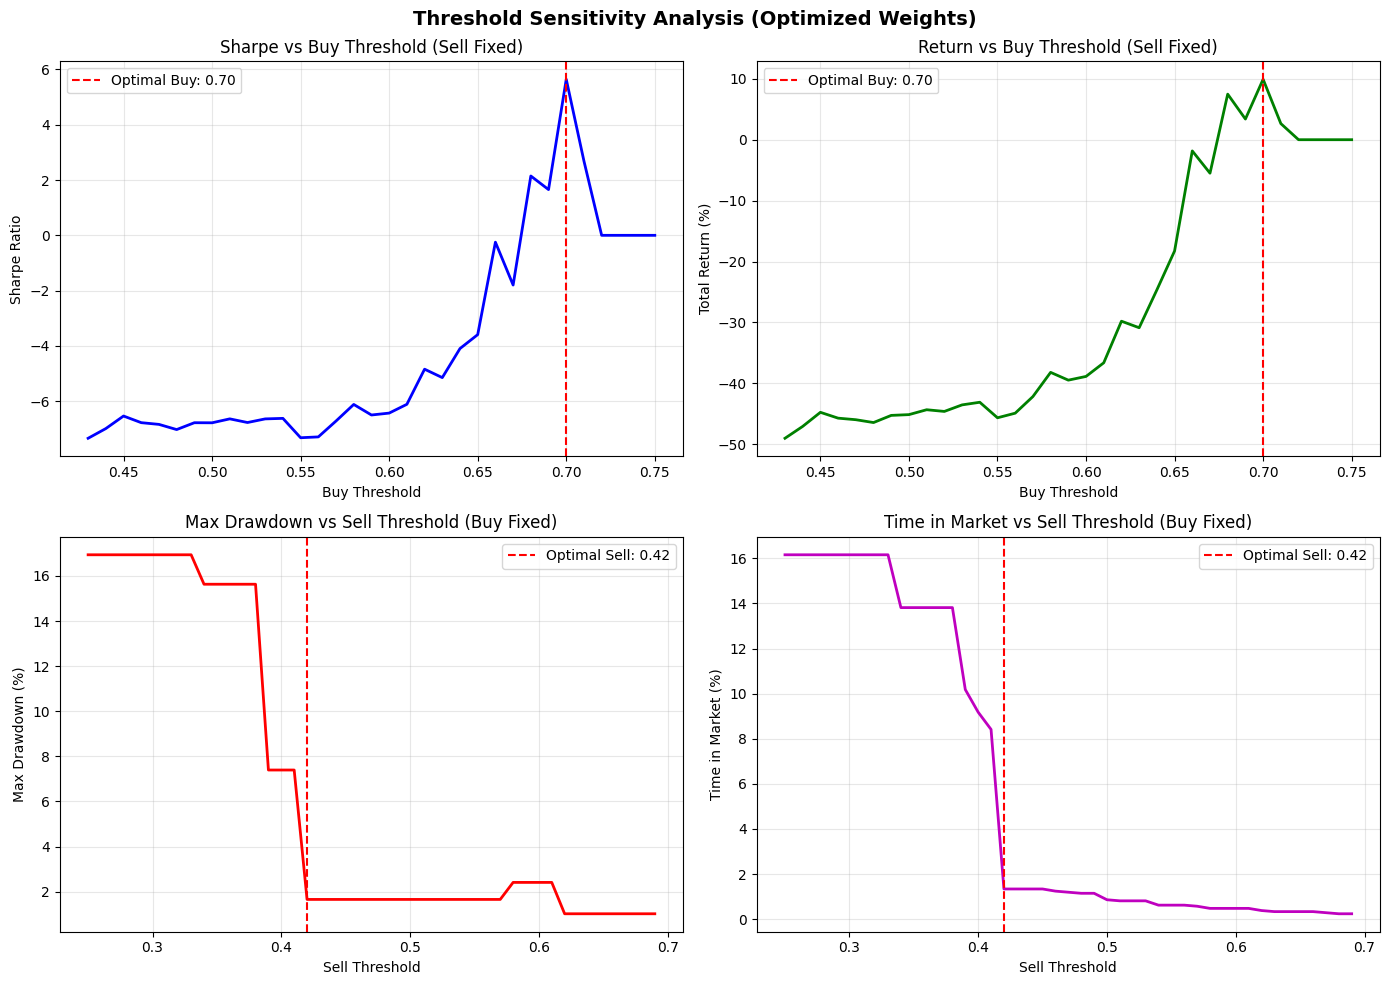


✅ Optimization complete. Results stored in OPTIMIZATION_RESULTS.


In [13]:
# ============================================================================
# WEIGHT & THRESHOLD OPTIMIZATION - FIND BEST PARAMETERS FOR MAXIMUM PERFORMANCE
# ============================================================================
# NOTE: All backtests now include TRADING COSTS of 0.1% per trade entry
from scipy.optimize import differential_evolution
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Prepare data for optimization
opt_df = df_multi_tf.copy()
opt_df = opt_df.set_index('datetime').sort_index()
opt_df['returns'] = opt_df['close'].pct_change()
opt_df = opt_df.dropna()

# Available probability columns
prob_cols_opt = ['prob_30m', 'prob_5m', 'prob_15m', 'prob_1h', 'prob_4h']
available_cols_opt = [col for col in prob_cols_opt if col in opt_df.columns]
n_weights = len(available_cols_opt)

print(f"🔧 WEIGHT & THRESHOLD OPTIMIZATION")
print(f"=" * 70)
print(f"Optimizing weights for: {available_cols_opt}")
print(f"Number of weights to optimize: {n_weights}")
print(f"Also optimizing: BUY_THRESHOLD, SELL_THRESHOLD, STOP_LOSS_PCT (entry/exit cutoffs + SL)")

# Optimization metric choices
OPTIMIZE_FOR = 'sharpe'  # Options: 'sharpe', 'return', 'profit_factor', 'calmar'

def backtest_with_weights_and_threshold(weights, buy_threshold, sell_threshold, stop_loss_pct):
    """Run backtest with given weights, thresholds, and stop loss, return performance metrics."""
    weights = np.array(weights)
    weights = weights / weights.sum()

    weighted_prob = sum(opt_df[col] * w for col, w in zip(available_cols_opt, weights))

    # Trading sim with stop loss
    TRADING_COST_PCT = 0.001  # 0.1% trading cost on entry
    position = 0
    signals = []
    equity = 1.0
    equity_curve = []
    entry_price = None

    for prob, ret, close in zip(weighted_prob, opt_df['returns'], opt_df['close']):
        if position == 1:
            equity *= (1 + ret)
            # Stop loss has priority over sell threshold
            if close <= entry_price * (1 - stop_loss_pct):
                position = 0
                entry_price = None
            elif prob <= sell_threshold:
                position = 0
                entry_price = None

        if position == 0 and prob >= buy_threshold:
            position = 1
            entry_price = close
            equity *= (1 - TRADING_COST_PCT)

        signals.append(position)
        equity_curve.append(equity)

    signal_series = pd.Series(signals, index=opt_df.index)
    strategy_equity = pd.Series(equity_curve, index=opt_df.index)
    strategy_returns = strategy_equity.pct_change().fillna(0)

    total_return = strategy_equity.iloc[-1] - 1
    if strategy_returns.std() > 0:
        sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(365 * 24 * 2)
    else:
        sharpe = 0

    cumulative = strategy_equity
    peak = cumulative.expanding(min_periods=1).max()
    drawdown = (cumulative - peak) / peak
    max_dd = abs(drawdown.min())

    gross_profits = strategy_returns[strategy_returns > 0].sum()
    gross_losses = abs(strategy_returns[strategy_returns < 0].sum())
    pf = gross_profits / gross_losses if gross_losses > 0 else 10

    calmar = total_return / max_dd if max_dd > 0 else total_return

    position_changes = signal_series.diff().fillna(0)
    num_trades = (position_changes == 1).sum()
    time_in_market = signal_series.mean() * 100

    return {
        'sharpe': sharpe,
        'return': total_return,
        'profit_factor': pf,
        'calmar': calmar,
        'max_dd': max_dd,
        'weights': weights,
        'buy_threshold': buy_threshold,
        'sell_threshold': sell_threshold,
        'stop_loss_pct': stop_loss_pct,
        'num_trades': num_trades,
        'time_in_market': time_in_market
    }

def objective_with_threshold(params):
    """Objective function: params = [weight1...weightN, buy_threshold, sell_threshold, stop_loss_pct]."""
    weights = params[:-3]
    buy_threshold = params[-3]
    sell_threshold = params[-2]
    stop_loss_pct = params[-1]
    if sell_threshold >= buy_threshold:
        return 1e6  # Penalize invalid threshold combinations
    result = backtest_with_weights_and_threshold(weights, buy_threshold, sell_threshold, stop_loss_pct)
    return -result[OPTIMIZE_FOR]  # Negative because we minimize

# ============================================================================
# METHOD 1: GRID SEARCH (Weights + Buy/Sell Thresholds + Stop Loss)
# ============================================================================
print(f"\n📊 METHOD 1: GRID SEARCH (Weights + Buy/Sell Thresholds + Stop Loss)")
print("-" * 70)

# Extended weight grid (0.0 to 1.0 in steps of 0.2 for speed)
weight_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
# Threshold ranges
buy_threshold_values = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
sell_threshold_values = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
# Stop loss range (fractional, e.g., 0.02 = 2%)
stop_loss_values = [0.01, 0.02, 0.03, 0.04, 0.05]

total_combinations = (
    (len(weight_values) ** n_weights)
    * len(buy_threshold_values)
    * len(sell_threshold_values)
    * len(stop_loss_values)
)
print(f"Weight values: {weight_values}")
print(f"Buy threshold values:  {buy_threshold_values}")
print(f"Sell threshold values: {sell_threshold_values}")
print(f"Stop loss values:      {stop_loss_values}")
print(f"Testing {total_combinations:,} combinations (weights × buy/sell thresholds × stop loss)...")

best_grid_result = None
best_grid_score = -np.inf
best_grid_buy_threshold = BUY_THRESHOLD if 'BUY_THRESHOLD' in dir() else 0.5
best_grid_sell_threshold = SELL_THRESHOLD if 'SELL_THRESHOLD' in dir() else 0.4
best_grid_stop_loss = STOP_LOSS_PCT if 'STOP_LOSS_PCT' in dir() else 0.02
grid_results = []

# Progress tracking
checked = 0
for buy_threshold in buy_threshold_values:
    for sell_threshold in sell_threshold_values:
        if sell_threshold >= buy_threshold:
            continue
        for stop_loss_pct in stop_loss_values:
            for weight_combo in product(weight_values, repeat=n_weights):
                if sum(weight_combo) == 0:
                    continue

                result = backtest_with_weights_and_threshold(weight_combo, buy_threshold, sell_threshold, stop_loss_pct)
                score = result[OPTIMIZE_FOR]

                grid_results.append({
                    'weights': weight_combo,
                    'buy_threshold': buy_threshold,
                    'sell_threshold': sell_threshold,
                    'stop_loss_pct': stop_loss_pct,
                    'sharpe': result['sharpe'],
                    'return': result['return'] * 100,
                    'profit_factor': result['profit_factor'],
                    'max_dd': result['max_dd'] * 100,
                    'num_trades': result['num_trades'],
                    'time_in_market': result['time_in_market']
                })

                if score > best_grid_score:
                    best_grid_score = score
                    best_grid_result = result
                    best_grid_buy_threshold = buy_threshold
                    best_grid_sell_threshold = sell_threshold
                    best_grid_stop_loss = stop_loss_pct

                checked += 1
                if checked % 5000 == 0:
                    print(f"   Checked {checked:,} combinations... (best {OPTIMIZE_FOR} so far: {best_grid_score:.4f})")

print(f"\n✅ Grid Search Complete!")
print(f"   Best {OPTIMIZE_FOR}: {best_grid_score:.4f}")
print(f"   Best BUY Threshold:  {best_grid_buy_threshold:.2f}")
print(f"   Best SELL Threshold: {best_grid_sell_threshold:.2f}")
print(f"   Best STOP LOSS:      {best_grid_stop_loss*100:.2f}%")
print(f"   Best Weights:")
for col, w in zip(available_cols_opt, best_grid_result['weights']):
    print(f"      {col.replace('prob_', ''):6s}: {w:.2f} ({w/sum(best_grid_result['weights'])*100:.1f}%)")

# ============================================================================
# METHOD 2: DIFFERENTIAL EVOLUTION (Global optimization with buy/sell thresholds + SL)
# ============================================================================
print(f"\n📊 METHOD 2: DIFFERENTIAL EVOLUTION (Global Optimization)")
print("-" * 70)

# Bounds: weights between 0.01 and 1.0, thresholds between 0.3 and 0.7, stop loss between 0.5% and 8%
bounds = [(0.01, 1.0)] * n_weights + [(0.30, 0.70), (0.30, 0.70), (0.005, 0.08)]
print(f"Weight bounds: (0.01, 1.0) for each timeframe")
print(f"Threshold bounds: BUY (0.30, 0.70), SELL (0.30, 0.70)")
print(f"Stop loss bounds: (0.005, 0.08)")

de_result = differential_evolution(
    objective_with_threshold,
    bounds,
    seed=42,
    maxiter=300,
    tol=1e-7,
    disp=False,
    workers=1,
    mutation=(0.5, 1.0),
    recombination=0.7,
    popsize=20
)

de_weights = de_result.x[:-3] / de_result.x[:-3].sum()  # Normalize weights
de_buy_threshold = de_result.x[-3]
de_sell_threshold = de_result.x[-2]
de_stop_loss = de_result.x[-1]
de_backtest = backtest_with_weights_and_threshold(de_result.x[:-3], de_buy_threshold, de_sell_threshold, de_stop_loss)

print(f"\n✅ Differential Evolution Complete!")
print(f"   Best {OPTIMIZE_FOR}: {-de_result.fun:.4f}")
print(f"   Best BUY Threshold:  {de_buy_threshold:.4f}")
print(f"   Best SELL Threshold: {de_sell_threshold:.4f}")
print(f"   Best STOP LOSS:      {de_stop_loss*100:.2f}%")
print(f"   Best Weights:")
for col, w in zip(available_cols_opt, de_weights):
    print(f"      {col.replace('prob_', ''):6s}: {w:.4f} ({w*100:.1f}%)")

# ============================================================================
# METHOD 3: FINE-GRAIN THRESHOLD SEARCH (using best weights from DE, fixed SL from DE)
# ============================================================================
print(f"\n📊 METHOD 3: FINE-GRAIN THRESHOLD SEARCH")
print("-" * 70)

fine_buy_thresholds = np.arange(0.25, 0.76, 0.01)
fine_sell_thresholds = np.arange(0.25, 0.76, 0.01)
best_fine_buy_threshold = de_buy_threshold
best_fine_sell_threshold = de_sell_threshold
best_fine_stop_loss = de_stop_loss
best_fine_score = -np.inf
best_fine_result = de_backtest
threshold_scan_results = []

for buy_th in fine_buy_thresholds:
    for sell_th in fine_sell_thresholds:
        if sell_th >= buy_th:
            continue
        result = backtest_with_weights_and_threshold(de_result.x[:-3], buy_th, sell_th, de_stop_loss)
        score = result[OPTIMIZE_FOR]
        threshold_scan_results.append({
            'buy_threshold': buy_th,
            'sell_threshold': sell_th,
            'stop_loss_pct': de_stop_loss,
            'sharpe': result['sharpe'],
            'return': result['return'] * 100,
            'profit_factor': result['profit_factor'],
            'max_dd': result['max_dd'] * 100,
            'time_in_market': result['time_in_market']
        })
        if score > best_fine_score:
            best_fine_score = score
            best_fine_buy_threshold = buy_th
            best_fine_sell_threshold = sell_th
            best_fine_result = result

print(f"   Scanned thresholds from 0.25 to 0.75 (step 0.01)")
print(f"   Best BUY Threshold:  {best_fine_buy_threshold:.2f}")
print(f"   Best SELL Threshold: {best_fine_sell_threshold:.2f}")
print(f"   Best STOP LOSS:      {best_fine_stop_loss*100:.2f}%")
print(f"   Best {OPTIMIZE_FOR}: {best_fine_score:.4f}")

# ============================================================================
# COMPARE ALL RESULTS
# ============================================================================
print(f"\n" + "=" * 70)
print(f"📊 OPTIMIZATION RESULTS COMPARISON")
print("=" * 70)

# Original weights from the backtest cell
original_weights = np.array([TIMEFRAME_WEIGHTS.get(col, 0.5) for col in available_cols_opt])
original_weights = original_weights / original_weights.sum()
original_buy_threshold = BUY_THRESHOLD if 'BUY_THRESHOLD' in dir() else 0.5
original_sell_threshold = SELL_THRESHOLD if 'SELL_THRESHOLD' in dir() else 0.4
original_stop_loss = STOP_LOSS_PCT if 'STOP_LOSS_PCT' in dir() else 0.02
original_result = backtest_with_weights_and_threshold(original_weights, original_buy_threshold, original_sell_threshold, original_stop_loss)

comparison_df = pd.DataFrame({
    'Method': ['Original', 'Grid Search', 'Diff. Evolution', 'Fine-Tuned'],
    'Buy Threshold': [original_buy_threshold, best_grid_buy_threshold, de_buy_threshold, best_fine_buy_threshold],
    'Sell Threshold': [original_sell_threshold, best_grid_sell_threshold, de_sell_threshold, best_fine_sell_threshold],
    'Stop Loss (%)': [original_stop_loss*100, best_grid_stop_loss*100, de_stop_loss*100, best_fine_stop_loss*100],
    'Sharpe': [original_result['sharpe'], best_grid_result['sharpe'], de_backtest['sharpe'], best_fine_result['sharpe']],
    'Return (%)': [original_result['return']*100, best_grid_result['return']*100, de_backtest['return']*100, best_fine_result['return']*100],
    'Profit Factor': [original_result['profit_factor'], best_grid_result['profit_factor'], de_backtest['profit_factor'], best_fine_result['profit_factor']],
    'Max DD (%)': [original_result['max_dd']*100, best_grid_result['max_dd']*100, de_backtest['max_dd']*100, best_fine_result['max_dd']*100],
    'Time in Market (%)': [original_result['time_in_market'], best_grid_result['time_in_market'], de_backtest['time_in_market'], best_fine_result['time_in_market']]
})

display(comparison_df.round(4))

# ============================================================================
# BEST PARAMETERS SUMMARY
# ============================================================================
print(f"\n" + "=" * 70)
print(f"🏆 OPTIMAL PARAMETERS (Optimized for {OPTIMIZE_FOR.upper()})")
print("=" * 70)

# Choose the best overall result
all_scores = [
    (original_result[OPTIMIZE_FOR], 'Original', original_result, original_buy_threshold, original_sell_threshold, original_weights, original_stop_loss),
    (best_grid_result[OPTIMIZE_FOR], 'Grid Search', best_grid_result, best_grid_buy_threshold, best_grid_sell_threshold, best_grid_result['weights'], best_grid_stop_loss),
    (de_backtest[OPTIMIZE_FOR], 'Diff. Evolution', de_backtest, de_buy_threshold, de_sell_threshold, de_weights, de_stop_loss),
    (best_fine_result[OPTIMIZE_FOR], 'Fine-Tuned', best_fine_result, best_fine_buy_threshold, best_fine_sell_threshold, de_weights, best_fine_stop_loss)
]
if isinstance(all_scores, tuple) and len(all_scores) == 1 and isinstance(all_scores[0], list):
    all_scores = all_scores[0]
best_score, best_method, best_result, best_buy_threshold, best_sell_threshold, best_weights, best_stop_loss = max(all_scores, key=lambda x: x[0])

# Normalize if needed
best_weights = np.array(best_weights)
best_weights = best_weights / best_weights.sum()

print(f"\n🥇 Best Method: {best_method}")
print(f"\n📌 OPTIMAL BUY THRESHOLD:  {best_buy_threshold:.4f}")
print(f"\n📌 OPTIMAL SELL THRESHOLD: {best_sell_threshold:.4f}")
print(f"\n📌 OPTIMAL STOP LOSS:      {best_stop_loss*100:.2f}%")
print(f"\n📌 OPTIMAL WEIGHTS:")
OPTIMAL_WEIGHTS = {}
OPTIMAL_BUY_THRESHOLD = best_buy_threshold
OPTIMAL_SELL_THRESHOLD = best_sell_threshold
OPTIMAL_STOP_LOSS = best_stop_loss
for col, w in zip(available_cols_opt, best_weights):
    tf_name = col.replace('prob_', '')
    OPTIMAL_WEIGHTS[col] = float(w)
    print(f"   {tf_name:6s}: {w:.4f} ({w*100:.1f}%)")

print(f"\n📈 PERFORMANCE WITH OPTIMAL PARAMETERS:")
print(f"   Sharpe Ratio:     {best_result['sharpe']:.4f}")
print(f"   Total Return:     {best_result['return']*100:.2f}%")
print(f"   Profit Factor:    {best_result['profit_factor']:.2f}")
print(f"   Max Drawdown:     {best_result['max_dd']*100:.2f}%")
print(f"   Time in Market:   {best_result['time_in_market']:.1f}%")
print(f"   Number of Trades: {best_result['num_trades']}")

print(f"\n💡 To use these parameters, update your backtest cell:")
print(f"   BUY_THRESHOLD = {best_buy_threshold:.4f}")
print(f"   SELL_THRESHOLD = {best_sell_threshold:.4f}")
print(f"   STOP_LOSS_PCT = {best_stop_loss:.4f}")
print(f"   TIMEFRAME_WEIGHTS = {{")
for col, w in zip(available_cols_opt, best_weights):
    print(f"       '{col}': {w:.4f},")
print(f"   }}")

# ============================================================================
# VISUALIZATION: Threshold Sensitivity (slice at best opposite threshold)
# ============================================================================
threshold_df = pd.DataFrame(threshold_scan_results)

buy_slice = threshold_df[np.isclose(threshold_df['sell_threshold'], best_fine_sell_threshold)]
sell_slice = threshold_df[np.isclose(threshold_df['buy_threshold'], best_fine_buy_threshold)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sharpe vs Buy Threshold (holding best sell threshold)
ax1 = axes[0, 0]
if len(buy_slice) > 0:
    ax1.plot(buy_slice['buy_threshold'], buy_slice['sharpe'], 'b-', linewidth=2)
    ax1.axvline(best_fine_buy_threshold, color='r', linestyle='--', label=f'Optimal Buy: {best_fine_buy_threshold:.2f}')
ax1.set_xlabel('Buy Threshold')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe vs Buy Threshold (Sell Fixed)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Return vs Buy Threshold (holding best sell threshold)
ax2 = axes[0, 1]
if len(buy_slice) > 0:
    ax2.plot(buy_slice['buy_threshold'], buy_slice['return'], 'g-', linewidth=2)
    ax2.axvline(best_fine_buy_threshold, color='r', linestyle='--', label=f'Optimal Buy: {best_fine_buy_threshold:.2f}')
ax2.set_xlabel('Buy Threshold')
ax2.set_ylabel('Total Return (%)')
ax2.set_title('Return vs Buy Threshold (Sell Fixed)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Max Drawdown vs Sell Threshold (holding best buy threshold)
ax3 = axes[1, 0]
if len(sell_slice) > 0:
    ax3.plot(sell_slice['sell_threshold'], sell_slice['max_dd'], 'r-', linewidth=2)
    ax3.axvline(best_fine_sell_threshold, color='r', linestyle='--', label=f'Optimal Sell: {best_fine_sell_threshold:.2f}')
ax3.set_xlabel('Sell Threshold')
ax3.set_ylabel('Max Drawdown (%)')
ax3.set_title('Max Drawdown vs Sell Threshold (Buy Fixed)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Time in Market vs Sell Threshold (holding best buy threshold)
ax4 = axes[1, 1]
if len(sell_slice) > 0:
    ax4.plot(sell_slice['sell_threshold'], sell_slice['time_in_market'], 'm-', linewidth=2)
    ax4.axvline(best_fine_sell_threshold, color='r', linestyle='--', label=f'Optimal Sell: {best_fine_sell_threshold:.2f}')
ax4.set_xlabel('Sell Threshold')
ax4.set_ylabel('Time in Market (%)')
ax4.set_title('Time in Market vs Sell Threshold (Buy Fixed)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Threshold Sensitivity Analysis (Optimized Weights)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Store all optimization results
OPTIMIZATION_RESULTS = {
    'best_method': best_method,
    'optimal_weights': OPTIMAL_WEIGHTS,
    'optimal_buy_threshold': OPTIMAL_BUY_THRESHOLD,
    'optimal_sell_threshold': OPTIMAL_SELL_THRESHOLD,
    'optimal_stop_loss_pct': OPTIMAL_STOP_LOSS,
    'sharpe': best_result['sharpe'],
    'total_return': best_result['return'],
    'profit_factor': best_result['profit_factor'],
    'max_drawdown': best_result['max_dd'],
    'time_in_market': best_result['time_in_market'],
    'num_trades': best_result['num_trades'],
    'grid_results': grid_results,
    'threshold_scan_results': threshold_scan_results,
    'comparison_df': comparison_df
}

print(f"\n✅ Optimization complete. Results stored in OPTIMIZATION_RESULTS.")

🔧 WEIGHT & THRESHOLD OPTIMIZATION (MAX RETURN)
Optimizing weights for: ['prob_30m', 'prob_5m', 'prob_15m', 'prob_1h', 'prob_4h']
Number of weights to optimize: 5
Also optimizing: BUY_THRESHOLD, SELL_THRESHOLD, STOP_LOSS_PCT (entry/exit cutoffs + SL)

📊 METHOD 1: GRID SEARCH (Weights + Buy/Sell Thresholds + Stop Loss) - MAX RETURN
----------------------------------------------------------------------
Weight values: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
Buy thresholds:  [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
Sell thresholds: [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
Stop loss values: [0.01, 0.02, 0.03, 0.04, 0.05]
Testing 3,149,280 combinations (weights × buy/sell thresholds × stop loss)...
   Checked 5,000 combinations... (best return so far: -6.95%)
   Checked 10,000 combinations... (best return so far: -6.07%)
   Checked 15,000 combinations... (best return so far: -6.00%)
   Checked 20,000 combinations... (best return so far: -5.24%)
   Checked 25,000 combinations... (best

,Method,Buy Threshold,Sell Threshold,Stop Loss (%),Total Return (%),Sharpe,Profit Factor,Max DD (%),Time in Market (%)
0,Original,0.6543,0.3921,4.2500,7.4370,2.4720,1.1204,6.2738,24.9062
1,Grid Search (Return),0.7000,0.3000,2.0000,18.4278,4.3571,1.1631,7.0412,49.7186
2,Diff. Evolution (Return),0.6946,0.3139,1.6915,18.3863,4.0044,1.1258,7.0412,64.8687
3,Fine-Tuned (Return),0.6900,0.3000,1.6915,18.3863,4.0044,1.1258,7.0412,64.8687



💰 OPTIMAL PARAMETERS (MAXIMIZING TOTAL RETURN)

🥇 Best Method: Grid Search

📌 OPTIMAL BUY THRESHOLD:  0.7000

📌 OPTIMAL SELL THRESHOLD: 0.3000

📌 OPTIMAL STOP LOSS:      2.00%

📌 OPTIMAL WEIGHTS:
   30m   : 0.5000 (50.0%)
   5m    : 0.0000 (0.0%)
   15m   : 0.0000 (0.0%)
   1h    : 0.1250 (12.5%)
   4h    : 0.3750 (37.5%)

💰 PERFORMANCE WITH OPTIMAL PARAMETERS:
   Total Return:     18.43%
   Sharpe Ratio:     4.3571
   Profit Factor:    1.16
   Max Drawdown:     7.04%
   Time in Market:   49.7%
   Number of Trades: 4

💡 To use these parameters, update your backtest cell:
   BUY_THRESHOLD = 0.7000
   SELL_THRESHOLD = 0.3000
   STOP_LOSS_PCT = 0.0200
   TIMEFRAME_WEIGHTS = {
       'prob_30m': 0.5000,
       'prob_5m': 0.0000,
       'prob_15m': 0.0000,
       'prob_1h': 0.1250,
       'prob_4h': 0.3750,
   }


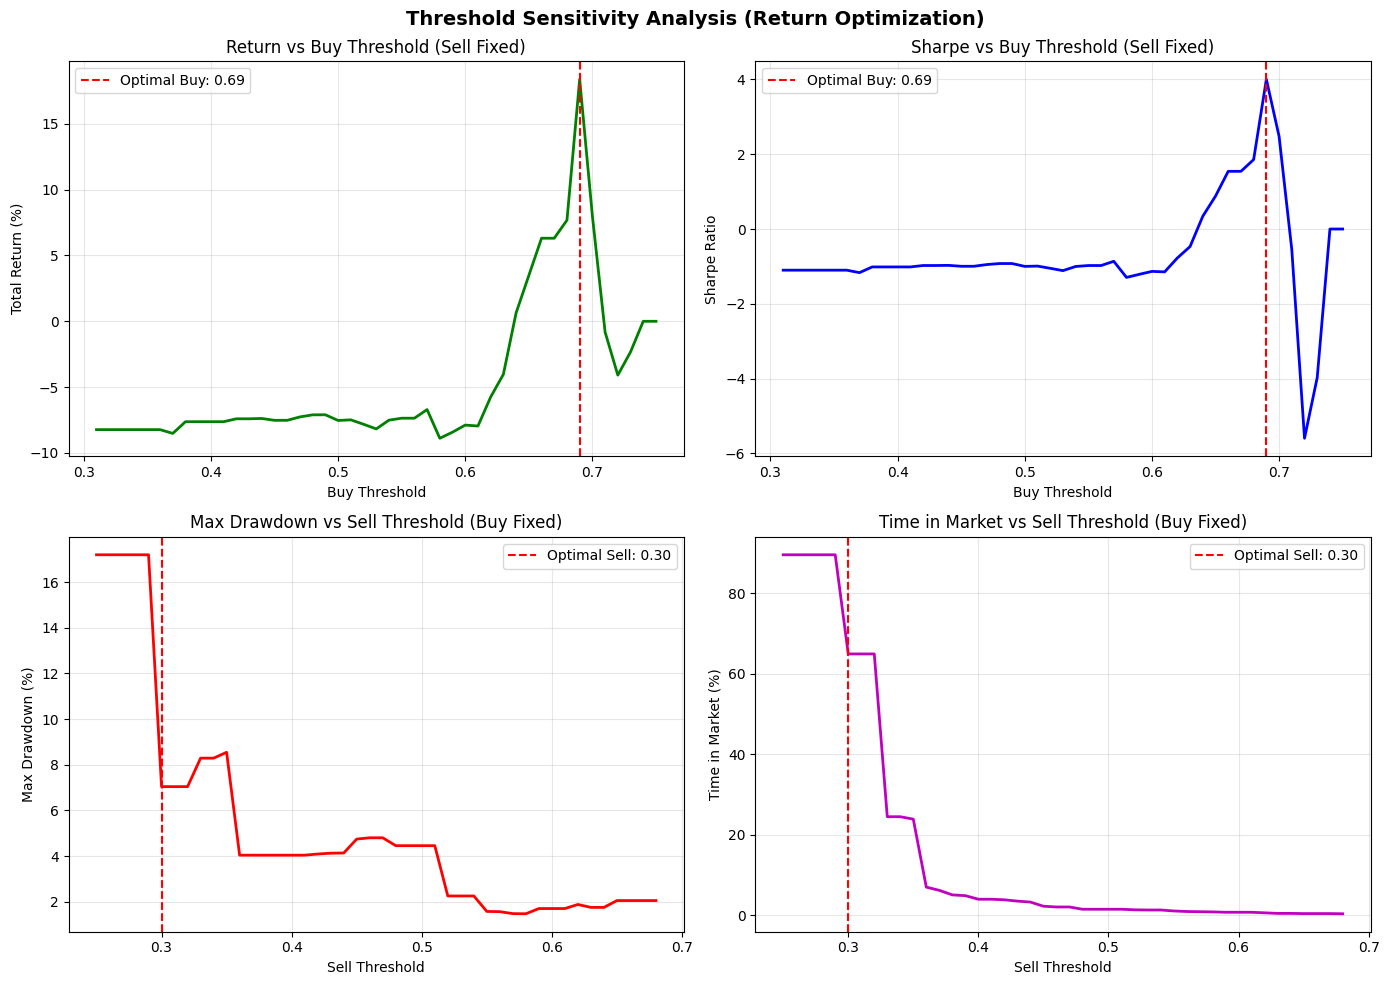


✅ Return optimization complete. Results stored in OPTIMIZATION_RESULTS_RETURN.


In [26]:
# ============================================================================
# WEIGHT & THRESHOLD OPTIMIZATION - PRIORITIZING TOTAL RETURN
# ============================================================================
# NOTE: All backtests now include TRADING COSTS of 0.1% per trade entry
from scipy.optimize import differential_evolution
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Prepare data for optimization
opt_df = df_multi_tf.copy()
opt_df = opt_df.set_index('datetime').sort_index()
opt_df['returns'] = opt_df['close'].pct_change()
opt_df = opt_df.dropna()

# Available probability columns
prob_cols_opt = ['prob_30m', 'prob_5m', 'prob_15m', 'prob_1h', 'prob_4h']
available_cols_opt = [col for col in prob_cols_opt if col in opt_df.columns]
n_weights = len(available_cols_opt)

print(f"🔧 WEIGHT & THRESHOLD OPTIMIZATION (MAX RETURN)")
print(f"=" * 70)
print(f"Optimizing weights for: {available_cols_opt}")
print(f"Number of weights to optimize: {n_weights}")
print(f"Also optimizing: BUY_THRESHOLD, SELL_THRESHOLD, STOP_LOSS_PCT (entry/exit cutoffs + SL)")

# Optimization metric choice for this cell
OPTIMIZE_FOR_RETURN = 'return'

def backtest_with_weights_and_threshold(weights, buy_threshold, sell_threshold, stop_loss_pct):
    """Backtest using weights, thresholds, and stop loss (hysteresis)."""
    weights = np.array(weights)
    weights = weights / weights.sum()

    weighted_prob = sum(opt_df[col] * w for col, w in zip(available_cols_opt, weights))

    TRADING_COST_PCT = 0.001  # 0.1%
    position = 0
    signals = []
    equity = 1.0
    equity_curve = []
    entry_price = None

    for prob, ret, close in zip(weighted_prob, opt_df['returns'], opt_df['close']):
        if position == 1:
            equity *= (1 + ret)
            if close <= entry_price * (1 - stop_loss_pct):
                position = 0
                entry_price = None
            elif prob <= sell_threshold:
                position = 0
                entry_price = None

        if position == 0 and prob >= buy_threshold:
            position = 1
            entry_price = close
            equity *= (1 - TRADING_COST_PCT)

        signals.append(position)
        equity_curve.append(equity)

    signal_series = pd.Series(signals, index=opt_df.index)
    strategy_equity = pd.Series(equity_curve, index=opt_df.index)
    strategy_returns = strategy_equity.pct_change().fillna(0)
    total_return = strategy_equity.iloc[-1] - 1

    if strategy_returns.std() > 0:
        sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(365 * 24 * 2)
    else:
        sharpe = 0

    cumulative = strategy_equity
    peak = cumulative.expanding(min_periods=1).max()
    drawdown = (cumulative - peak) / peak
    max_dd = abs(drawdown.min())

    gross_profits = strategy_returns[strategy_returns > 0].sum()
    gross_losses = abs(strategy_returns[strategy_returns < 0].sum())
    pf = gross_profits / gross_losses if gross_losses > 0 else 10

    calmar = total_return / max_dd if max_dd > 0 else total_return

    position_changes = signal_series.diff().fillna(0)
    num_trades = (position_changes == 1).sum()
    time_in_market = signal_series.mean() * 100

    return {
        'sharpe': sharpe,
        'return': total_return,
        'profit_factor': pf,
        'calmar': calmar,
        'max_dd': max_dd,
        'weights': weights,
        'buy_threshold': buy_threshold,
        'sell_threshold': sell_threshold,
        'stop_loss_pct': stop_loss_pct,
        'num_trades': num_trades,
        'time_in_market': time_in_market
    }

def objective_return(params):
    """Objective: maximize total return (negative for minimizer)."""
    weights = params[:-3]
    buy_threshold = params[-3]
    sell_threshold = params[-2]
    stop_loss_pct = params[-1]
    if sell_threshold >= buy_threshold:
        return 1e6
    result = backtest_with_weights_and_threshold(weights, buy_threshold, sell_threshold, stop_loss_pct)
    return -result[OPTIMIZE_FOR_RETURN]

# ============================================================================
# METHOD 1: GRID SEARCH (Weights + Buy/Sell Thresholds + Stop Loss) - MAX RETURN
# ============================================================================
print(f"\n📊 METHOD 1: GRID SEARCH (Weights + Buy/Sell Thresholds + Stop Loss) - MAX RETURN")
print("-" * 70)

weight_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
buy_threshold_values = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
sell_threshold_values = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
stop_loss_values = [0.01, 0.02, 0.03, 0.04, 0.05]

total_combinations = (
    (len(weight_values) ** n_weights)
    * len(buy_threshold_values)
    * len(sell_threshold_values)
    * len(stop_loss_values)
)
print(f"Weight values: {weight_values}")
print(f"Buy thresholds:  {buy_threshold_values}")
print(f"Sell thresholds: {sell_threshold_values}")
print(f"Stop loss values: {stop_loss_values}")
print(f"Testing {total_combinations:,} combinations (weights × buy/sell thresholds × stop loss)...")

best_grid_result_return = None
best_grid_score_return = -np.inf
best_grid_buy_threshold_return = BUY_THRESHOLD if 'BUY_THRESHOLD' in dir() else 0.5
best_grid_sell_threshold_return = SELL_THRESHOLD if 'SELL_THRESHOLD' in dir() else 0.4
best_grid_stop_loss_return = STOP_LOSS_PCT if 'STOP_LOSS_PCT' in dir() else 0.02
grid_results_return = []

checked = 0
for buy_threshold in buy_threshold_values:
    for sell_threshold in sell_threshold_values:
        if sell_threshold >= buy_threshold:
            continue
        for stop_loss_pct in stop_loss_values:
            for weight_combo in product(weight_values, repeat=n_weights):
                if sum(weight_combo) == 0:
                    continue
                result = backtest_with_weights_and_threshold(weight_combo, buy_threshold, sell_threshold, stop_loss_pct)
                score = result[OPTIMIZE_FOR_RETURN]
                grid_results_return.append({
                    'weights': weight_combo,
                    'buy_threshold': buy_threshold,
                    'sell_threshold': sell_threshold,
                    'stop_loss_pct': stop_loss_pct,
                    'sharpe': result['sharpe'],
                    'return': result['return'] * 100,
                    'profit_factor': result['profit_factor'],
                    'max_dd': result['max_dd'] * 100,
                    'num_trades': result['num_trades'],
                    'time_in_market': result['time_in_market']
                })
                if score > best_grid_score_return:
                    best_grid_score_return = score
                    best_grid_result_return = result
                    best_grid_buy_threshold_return = buy_threshold
                    best_grid_sell_threshold_return = sell_threshold
                    best_grid_stop_loss_return = stop_loss_pct
                checked += 1
                if checked % 5000 == 0:
                    print(f"   Checked {checked:,} combinations... (best return so far: {best_grid_score_return*100:.2f}%)")

print(f"\n✅ Grid Search Complete!")
print(f"   Best Total Return: {best_grid_score_return*100:.2f}%")
print(f"   Best BUY Threshold:  {best_grid_buy_threshold_return:.2f}")
print(f"   Best SELL Threshold: {best_grid_sell_threshold_return:.2f}")
print(f"   Best STOP LOSS:      {best_grid_stop_loss_return*100:.2f}%")
print(f"   Best Weights:")
for col, w in zip(available_cols_opt, best_grid_result_return['weights']):
    print(f"      {col.replace('prob_', ''):6s}: {w:.2f} ({w/sum(best_grid_result_return['weights'])*100:.1f}%)")

# ============================================================================
# METHOD 2: DIFFERENTIAL EVOLUTION (Global optimization) - MAX RETURN
# ============================================================================
print(f"\n📊 METHOD 2: DIFFERENTIAL EVOLUTION (Global Optimization) - MAX RETURN")
print("-" * 70)

bounds = [(0.01, 1.0)] * n_weights + [(0.30, 0.70), (0.30, 0.70), (0.005, 0.08)]
print(f"Weight bounds: (0.01, 1.0) for each timeframe")
print(f"Threshold bounds: BUY (0.30, 0.70), SELL (0.30, 0.70)")
print(f"Stop loss bounds: (0.005, 0.08)")

de_result_return = differential_evolution(
    objective_return,
    bounds,
    seed=42,
    maxiter=400,
    tol=1e-7,
    disp=False,
    workers=1,
    mutation=(0.5, 1.0),
    recombination=0.7,
    popsize=25
)

de_weights_return = de_result_return.x[:-3] / de_result_return.x[:-3].sum()
de_buy_threshold_return = de_result_return.x[-3]
de_sell_threshold_return = de_result_return.x[-2]
de_stop_loss_return = de_result_return.x[-1]
de_backtest_return = backtest_with_weights_and_threshold(de_result_return.x[:-3], de_buy_threshold_return, de_sell_threshold_return, de_stop_loss_return)

print(f"\n✅ Differential Evolution Complete!")
print(f"   Best Total Return: {de_backtest_return['return']*100:.2f}%")
print(f"   Best BUY Threshold:  {de_buy_threshold_return:.4f}")
print(f"   Best SELL Threshold: {de_sell_threshold_return:.4f}")
print(f"   Best STOP LOSS:      {de_stop_loss_return*100:.2f}%")
print(f"   Best Weights:")
for col, w in zip(available_cols_opt, de_weights_return):
    print(f"      {col.replace('prob_', ''):6s}: {w:.4f} ({w*100:.1f}%)")

# ============================================================================
# METHOD 3: FINE-GRAIN THRESHOLD SEARCH (using best weights from DE) - MAX RETURN
# ============================================================================
print(f"\n📊 METHOD 3: FINE-GRAIN THRESHOLD SEARCH - MAX RETURN")
print("-" * 70)

fine_buy_thresholds = np.arange(0.25, 0.76, 0.01)
fine_sell_thresholds = np.arange(0.25, 0.76, 0.01)
best_fine_buy_threshold_return = de_buy_threshold_return
best_fine_sell_threshold_return = de_sell_threshold_return
best_fine_stop_loss_return = de_stop_loss_return
best_fine_score_return = -np.inf
best_fine_result_return = de_backtest_return
threshold_scan_results_return = []

for buy_th in fine_buy_thresholds:
    for sell_th in fine_sell_thresholds:
        if sell_th >= buy_th:
            continue
        result = backtest_with_weights_and_threshold(de_result_return.x[:-3], buy_th, sell_th, de_stop_loss_return)
        score = result[OPTIMIZE_FOR_RETURN]
        threshold_scan_results_return.append({
            'buy_threshold': buy_th,
            'sell_threshold': sell_th,
            'stop_loss_pct': de_stop_loss_return,
            'sharpe': result['sharpe'],
            'return': result['return'] * 100,
            'profit_factor': result['profit_factor'],
            'max_dd': result['max_dd'] * 100,
            'time_in_market': result['time_in_market']
        })
        if score > best_fine_score_return:
            best_fine_score_return = score
            best_fine_buy_threshold_return = buy_th
            best_fine_sell_threshold_return = sell_th
            best_fine_result_return = result

print(f"   Scanned thresholds from 0.25 to 0.75 (step 0.01)")
print(f"   Best BUY Threshold:  {best_fine_buy_threshold_return:.2f}")
print(f"   Best SELL Threshold: {best_fine_sell_threshold_return:.2f}")
print(f"   Best STOP LOSS:      {best_fine_stop_loss_return*100:.2f}%")
print(f"   Best Total Return: {best_fine_score_return*100:.2f}%")

# ============================================================================
# COMPARE ALL RESULTS - MAX RETURN OPTIMIZATION
# ============================================================================
print(f"\n" + "=" * 70)
print(f"📊 MAX RETURN OPTIMIZATION RESULTS COMPARISON")
print("=" * 70)

original_weights = np.array([TIMEFRAME_WEIGHTS.get(col, 0.5) for col in available_cols_opt])
original_weights = original_weights / original_weights.sum()
original_buy_threshold = BUY_THRESHOLD if 'BUY_THRESHOLD' in dir() else 0.5
original_sell_threshold = SELL_THRESHOLD if 'SELL_THRESHOLD' in dir() else 0.4
original_stop_loss = STOP_LOSS_PCT if 'STOP_LOSS_PCT' in dir() else 0.02
original_result = backtest_with_weights_and_threshold(original_weights, original_buy_threshold, original_sell_threshold, original_stop_loss)

comparison_df_return = pd.DataFrame({
    'Method': ['Original', 'Grid Search (Return)', 'Diff. Evolution (Return)', 'Fine-Tuned (Return)'],
    'Buy Threshold': [original_buy_threshold, best_grid_buy_threshold_return, de_buy_threshold_return, best_fine_buy_threshold_return],
    'Sell Threshold': [original_sell_threshold, best_grid_sell_threshold_return, de_sell_threshold_return, best_fine_sell_threshold_return],
    'Stop Loss (%)': [original_stop_loss*100, best_grid_stop_loss_return*100, de_stop_loss_return*100, best_fine_stop_loss_return*100],
    'Total Return (%)': [original_result['return']*100, best_grid_result_return['return']*100, de_backtest_return['return']*100, best_fine_result_return['return']*100],
    'Sharpe': [original_result['sharpe'], best_grid_result_return['sharpe'], de_backtest_return['sharpe'], best_fine_result_return['sharpe']],
    'Profit Factor': [original_result['profit_factor'], best_grid_result_return['profit_factor'], de_backtest_return['profit_factor'], best_fine_result_return['profit_factor']],
    'Max DD (%)': [original_result['max_dd']*100, best_grid_result_return['max_dd']*100, de_backtest_return['max_dd']*100, best_fine_result_return['max_dd']*100],
    'Time in Market (%)': [original_result['time_in_market'], best_grid_result_return['time_in_market'], de_backtest_return['time_in_market'], best_fine_result_return['time_in_market']]
})

display(comparison_df_return.round(4))

# ============================================================================
# BEST PARAMETERS SUMMARY - MAX RETURN OPTIMIZATION
# ============================================================================
print(f"\n" + "=" * 70)
print(f"💰 OPTIMAL PARAMETERS (MAXIMIZING TOTAL RETURN)")
print("=" * 70)

all_scores_return = [
    (original_result[OPTIMIZE_FOR_RETURN], 'Original', original_result, original_buy_threshold, original_sell_threshold, original_weights, original_stop_loss),
    (best_grid_result_return[OPTIMIZE_FOR_RETURN], 'Grid Search', best_grid_result_return, best_grid_buy_threshold_return, best_grid_sell_threshold_return, best_grid_result_return['weights'], best_grid_stop_loss_return),
    (de_backtest_return[OPTIMIZE_FOR_RETURN], 'Diff. Evolution', de_backtest_return, de_buy_threshold_return, de_sell_threshold_return, de_weights_return, de_stop_loss_return),
    (best_fine_result_return[OPTIMIZE_FOR_RETURN], 'Fine-Tuned', best_fine_result_return, best_fine_buy_threshold_return, best_fine_sell_threshold_return, de_weights_return, best_fine_stop_loss_return)
 ]
best_score_return, best_method_return, best_result_return, best_buy_threshold_return, best_sell_threshold_return, best_weights_return, best_stop_loss_return = max(all_scores_return, key=lambda x: x[0])

best_weights_return = np.array(best_weights_return)
best_weights_return = best_weights_return / best_weights_return.sum()

print(f"\n🥇 Best Method: {best_method_return}")
print(f"\n📌 OPTIMAL BUY THRESHOLD:  {best_buy_threshold_return:.4f}")
print(f"\n📌 OPTIMAL SELL THRESHOLD: {best_sell_threshold_return:.4f}")
print(f"\n📌 OPTIMAL STOP LOSS:      {best_stop_loss_return*100:.2f}%")
print(f"\n📌 OPTIMAL WEIGHTS:")
OPTIMAL_WEIGHTS_RETURN = {}
OPTIMAL_BUY_THRESHOLD_RETURN = best_buy_threshold_return
OPTIMAL_SELL_THRESHOLD_RETURN = best_sell_threshold_return
OPTIMAL_STOP_LOSS_RETURN = best_stop_loss_return
for col, w in zip(available_cols_opt, best_weights_return):
    tf_name = col.replace('prob_', '')
    OPTIMAL_WEIGHTS_RETURN[col] = float(w)
    print(f"   {tf_name:6s}: {w:.4f} ({w*100:.1f}%)")

print(f"\n💰 PERFORMANCE WITH OPTIMAL PARAMETERS:")
print(f"   Total Return:     {best_result_return['return']*100:.2f}%")
print(f"   Sharpe Ratio:     {best_result_return['sharpe']:.4f}")
print(f"   Profit Factor:    {best_result_return['profit_factor']:.2f}")
print(f"   Max Drawdown:     {best_result_return['max_dd']*100:.2f}%")
print(f"   Time in Market:   {best_result_return['time_in_market']:.1f}%")
print(f"   Number of Trades: {best_result_return['num_trades']}")

print(f"\n💡 To use these parameters, update your backtest cell:")
print(f"   BUY_THRESHOLD = {best_buy_threshold_return:.4f}")
print(f"   SELL_THRESHOLD = {best_sell_threshold_return:.4f}")
print(f"   STOP_LOSS_PCT = {best_stop_loss_return:.4f}")
print(f"   TIMEFRAME_WEIGHTS = {{")
for col, w in zip(available_cols_opt, best_weights_return):
    print(f"       '{col}': {w:.4f},")
print(f"   }}")

# ============================================================================
# VISUALIZATION: Threshold Sensitivity (Return Optimization)
# ============================================================================
threshold_df_return = pd.DataFrame(threshold_scan_results_return)

buy_slice = threshold_df_return[np.isclose(threshold_df_return['sell_threshold'], best_fine_sell_threshold_return)]
sell_slice = threshold_df_return[np.isclose(threshold_df_return['buy_threshold'], best_fine_buy_threshold_return)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Return vs Buy Threshold (holding best sell threshold)
ax1 = axes[0, 0]
if len(buy_slice) > 0:
    ax1.plot(buy_slice['buy_threshold'], buy_slice['return'], 'g-', linewidth=2)
    ax1.axvline(best_fine_buy_threshold_return, color='r', linestyle='--', label=f'Optimal Buy: {best_fine_buy_threshold_return:.2f}')
ax1.set_xlabel('Buy Threshold')
ax1.set_ylabel('Total Return (%)')
ax1.set_title('Return vs Buy Threshold (Sell Fixed)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Sharpe vs Buy Threshold (holding best sell threshold)
ax2 = axes[0, 1]
if len(buy_slice) > 0:
    ax2.plot(buy_slice['buy_threshold'], buy_slice['sharpe'], 'b-', linewidth=2)
    ax2.axvline(best_fine_buy_threshold_return, color='r', linestyle='--', label=f'Optimal Buy: {best_fine_buy_threshold_return:.2f}')
ax2.set_xlabel('Buy Threshold')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('Sharpe vs Buy Threshold (Sell Fixed)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Max Drawdown vs Sell Threshold (holding best buy threshold)
ax3 = axes[1, 0]
if len(sell_slice) > 0:
    ax3.plot(sell_slice['sell_threshold'], sell_slice['max_dd'], 'r-', linewidth=2)
    ax3.axvline(best_fine_sell_threshold_return, color='r', linestyle='--', label=f'Optimal Sell: {best_fine_sell_threshold_return:.2f}')
ax3.set_xlabel('Sell Threshold')
ax3.set_ylabel('Max Drawdown (%)')
ax3.set_title('Max Drawdown vs Sell Threshold (Buy Fixed)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Time in Market vs Sell Threshold (holding best buy threshold)
ax4 = axes[1, 1]
if len(sell_slice) > 0:
    ax4.plot(sell_slice['sell_threshold'], sell_slice['time_in_market'], 'm-', linewidth=2)
    ax4.axvline(best_fine_sell_threshold_return, color='r', linestyle='--', label=f'Optimal Sell: {best_fine_sell_threshold_return:.2f}')
ax4.set_xlabel('Sell Threshold')
ax4.set_ylabel('Time in Market (%)')
ax4.set_title('Time in Market vs Sell Threshold (Buy Fixed)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Threshold Sensitivity Analysis (Return Optimization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Store all optimization results for return maximization
OPTIMIZATION_RESULTS_RETURN = {
    'best_method': best_method_return,
    'optimal_weights': OPTIMAL_WEIGHTS_RETURN,
    'optimal_buy_threshold': OPTIMAL_BUY_THRESHOLD_RETURN,
    'optimal_sell_threshold': OPTIMAL_SELL_THRESHOLD_RETURN,
    'optimal_stop_loss_pct': OPTIMAL_STOP_LOSS_RETURN,
    'total_return': best_result_return['return'],
    'sharpe': best_result_return['sharpe'],
    'profit_factor': best_result_return['profit_factor'],
    'max_drawdown': best_result_return['max_dd'],
    'time_in_market': best_result_return['time_in_market'],
    'num_trades': best_result_return['num_trades'],
    'grid_results': grid_results_return,
    'threshold_scan_results': threshold_scan_results_return,
    'comparison_df': comparison_df_return
}

print(f"\n✅ Return optimization complete. Results stored in OPTIMIZATION_RESULTS_RETURN.")

## 2️⃣ Fetch Fresh Data from yfinance

In [66]:
# Fetch recent data from yfinance
# Using 60 days of data to ensure enough history for indicators
print(f"📥 Fetching {SYMBOL} data ({TIMEFRAME} timeframe)...")

ticker = yf.Ticker(SYMBOL)
df = ticker.history(period="60d", interval=TIMEFRAME)

# Clean column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Remove unnecessary columns
df.drop(columns=['Dividends', 'Stock_Splits'], errors='ignore', inplace=True)

print(f"✅ Data fetched: {len(df)} rows")
print(f"   Date range: {df.index.min()} to {df.index.max()}")
df.tail()

📥 Fetching ETH-USD data (30m timeframe)...
✅ Data fetched: 2672 rows
   Date range: 2025-11-21 10:30:00+00:00 to 2026-01-18 10:00:00+00:00


,Open,High,Low,Close,Volume
Datetime,,,,,
2026-01-18 08:00:00+00:00,3306.151367,3309.012451,3303.182129,3309.012451,213940224
2026-01-18 08:30:00+00:00,3308.747314,3314.629639,3308.747314,3314.469238,76307456
2026-01-18 09:00:00+00:00,3314.226807,3320.260498,3313.958008,3319.562012,236511232
2026-01-18 09:30:00+00:00,3320.811279,3322.881592,3320.140625,3322.822266,138276864
2026-01-18 10:00:00+00:00,3322.118896,3322.353271,3317.556641,3319.668945,82505728


## 3️⃣ Calculate Technical Indicators

Replicate the exact same indicators used during training.

In [6]:
def calculate_indicators(df):
    """
    Calculate technical indicators matching the training pipeline.
    """
    df = df.copy()
    
    # Target variable (for reference)
    df["return"] = df["Close"].pct_change()
    df["target"] = (df["return"].shift(-1) > 0).astype(int)
    
    # -----------------------------
    # HTF (Higher Timeframe) features
    # -----------------------------
    # Your model expects these 1D (daily) previous-bar features:
    # - HTF_1d_Close_prev
    # - HTF_1d_Return_prev
    # - HTF_1d_LogReturn_prev
    # We compute them from intraday data by resampling to 1D and forward-filling
    # back to the intraday index.
    try:
        daily_close = df["Close"].resample("1D").last()
        daily_ret = daily_close.pct_change()
        daily_logret = np.log(daily_close / daily_close.shift(1))
        
        daily_features = pd.DataFrame({
            "HTF_1d_Close_prev": daily_close.shift(1),
            "HTF_1d_Return_prev": daily_ret.shift(1),
            "HTF_1d_LogReturn_prev": daily_logret.shift(1),
        })
        
        # Align daily features to intraday timestamps via forward-fill
        daily_features_intraday = daily_features.reindex(df.index, method="ffill")
        df = df.join(daily_features_intraday)
    except Exception as e:
        print(f"⚠️ HTF feature calculation failed: {e}")
        df["HTF_1d_Close_prev"] = np.nan
        df["HTF_1d_Return_prev"] = np.nan
        df["HTF_1d_LogReturn_prev"] = np.nan
    
    # Trend Indicators
    df["EMA_20"] = tal.EMA(df["Close"], timeperiod=20)
    df["SAR"] = tal.SAR(df['High'], df['Low'], acceleration=0.02, maximum=0.2)
    
    # Momentum Indicators
    df["RSI_20"] = tal.RSI(df["Close"], timeperiod=20)
    df["ROC_10"] = df["Close"].pct_change(10)
    df['CCI_20'] = tal.CCI(df['High'], df['Low'], df['Close'], timeperiod=20)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = tal.MACD(df['Close'])
    
    # Volatility Indicators
    df["ATR_14"] = tal.ATR(df['High'], df['Low'], df['Close'], timeperiod=14)
    sma = df["Close"].rolling(20).mean()
    std = df["Close"].rolling(20).std()
    df["BB_upper"] = sma + (std * 2)
    df["BB_lower"] = sma - (std * 2)
    df["BW_20"] = (df["BB_upper"] - df["BB_lower"]) / sma
    
    # Volume Indicator (Chaikin Money Flow - 20 period)
    df['MF'] = (((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'])) * df['Volume']
    df["CMF_20"] = df['MF'].rolling(window=20).sum() / df['Volume'].rolling(window=20).sum()
    df.drop(columns=['MF'], inplace=True)
    
    # Price-based Indicators
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
    
    # Lag features
    for i in range(1, 6):
        df[f"Lag_{i}"] = df["return"].shift(i)
    
    # Drop unnecessary columns
    df.drop(columns=['Open', 'High', 'Low', 'BB_upper', 'BB_lower'], inplace=True, errors='ignore')
    
    # Drop NaN rows
    df = df.dropna()
    
    return df

# Apply indicators
df_processed = calculate_indicators(df)
print(f"✅ Indicators calculated. Shape: {df_processed.shape}")
print(f"   Features: {df_processed.columns.tolist()}")

✅ Indicators calculated. Shape: (2368, 24)
   Features: ['Close', 'Volume', 'return', 'target', 'HTF_1d_Close_prev', 'HTF_1d_Return_prev', 'HTF_1d_LogReturn_prev', 'EMA_20', 'SAR', 'RSI_20', 'ROC_10', 'CCI_20', 'MACD', 'MACD_signal', 'MACD_hist', 'ATR_14', 'BW_20', 'CMF_20', 'Log_Return', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5']


## 4️⃣ Prepare Features for Prediction

In [7]:
# Extract features (excluding target, return, Close, Volume)
feature_cols = [col for col in df_processed.columns if col not in ['target', 'return', 'Close', 'Volume']]
X = df_processed[feature_cols].copy()

print(f"📊 Feature matrix shape: {X.shape}")
print(f"   Feature columns: {feature_cols}")

📊 Feature matrix shape: (2368, 20)
   Feature columns: ['HTF_1d_Close_prev', 'HTF_1d_Return_prev', 'HTF_1d_LogReturn_prev', 'EMA_20', 'SAR', 'RSI_20', 'ROC_10', 'CCI_20', 'MACD', 'MACD_signal', 'MACD_hist', 'ATR_14', 'BW_20', 'CMF_20', 'Log_Return', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5']


## 5️⃣ Make Predictions

In [27]:
# Determine which features to use based on the selected model's feature set
print("\n" + "=" * 70)
print("🔍 FEATURE VERIFICATION")
print("=" * 70)

if FEATURE_COLUMNS_LOADED and features_config:
    # Get both feature sets from features.json
    X_features = features_config.get('X_features', [])
    X_full_features = features_config.get('X_full_features', [])
    best_model_feature_set = features_config.get('best_model_feature_set', 'X')
    
    print(f"\n📋 Features from features.json:")
    print(f"   X_features (basic):      {len(X_features)} features")
    print(f"   X_full_features (full):  {len(X_full_features)} features")
    print(f"   Best model feature set:  {best_model_feature_set}")
    
    # Determine which feature set to use based on selected model
    if SELECTED_FEATURE_SET == 'X':
        trained_features = X_features
        print(f"\n✅ Using X_features ({len(trained_features)} features) for model: {SELECTED_MODEL_NAME}")
    elif SELECTED_FEATURE_SET in ['X_full', 'Full']:
        trained_features = X_full_features
        print(f"\n✅ Using X_full_features ({len(trained_features)} features) for model: {SELECTED_MODEL_NAME}")
    else:
        # Fallback: try to match or use all
        print(f"\n⚠️ Unknown feature set '{SELECTED_FEATURE_SET}', attempting to match...")
        trained_features = X_full_features if len(X_full_features) > len(X_features) else X_features
    
    print(f"\n📊 Selected Features ({len(trained_features)}):")
    for i, feat in enumerate(trained_features, 1):
        print(f"   {i:2d}. {feat}")
    
    # Show difference between X and X_full
    extra_in_full = set(X_full_features) - set(X_features)
    if extra_in_full:
        print(f"\n📌 Extra features in X_full (not in X): {list(extra_in_full)}")
else:
    # Fallback: Get the feature names from the model itself (sklearn models only)
    print("⚠️ features.json not loaded - extracting features from model")
    
    if SELECTED_MODEL_TYPE in ['sklearn', 'pkl']:
        if hasattr(selected_model, 'feature_name_'):
            trained_features = list(selected_model.feature_name_)
        elif hasattr(selected_model, 'booster_') and hasattr(selected_model.booster_, 'feature_name'):
            trained_features = selected_model.booster_.feature_name()
        elif hasattr(selected_model, 'feature_names_in_'):
            trained_features = list(selected_model.feature_names_in_)
        elif hasattr(selected_model, 'n_features_in_'):
            n_features = selected_model.n_features_in_
            trained_features = feature_cols[:n_features]
            print(f"⚠️ Using first {n_features} features: {trained_features}")
        else:
            trained_features = feature_cols
            print(f"⚠️ Could not determine features from model, using all: {trained_features}")
        
        print(f"📋 Extracted {len(trained_features)} features from sklearn model")
    elif SELECTED_MODEL_TYPE == 'keras':
        # Keras models don't store feature names - need features.json or use input shape
        if hasattr(selected_model, 'input_shape'):
            n_features = selected_model.input_shape[-1]
            trained_features = feature_cols[:n_features]
            print(f"⚠️ Keras model expects {n_features} features, using first {n_features}")
        else:
            trained_features = feature_cols
            print(f"⚠️ Could not determine features from Keras model, using all")

print("=" * 70)

# Verify all required features exist in the processed data
missing_features = [f for f in trained_features if f not in X.columns]
extra_features = [f for f in X.columns if f not in trained_features]

print(f"\n🔎 Feature Matching Report:")
print(f"   Required features:  {len(trained_features)}")
print(f"   Available features: {len(X.columns)}")

if missing_features:
    print(f"\n❌ MISSING FEATURES ({len(missing_features)}):")
    for feat in missing_features:
        print(f"   - {feat}")
    raise ValueError(f"The following features are missing from the data: {missing_features}")
else:
    print(f"   ✅ All required features are present")

if extra_features:
    print(f"\n📌 Extra features in data (not used): {extra_features}")

# Filter X to only include the trained features (and in the same order)
X_filtered = X[trained_features].copy()
print(f"\n✅ Features filtered and ordered: {X_filtered.shape}")

# Z-score scale features WITHOUT using the saved scaler
from sklearn.preprocessing import StandardScaler
zscore_scaler = StandardScaler()
X_scaled_filtered = zscore_scaler.fit_transform(X_filtered)
print("✅ Features scaled using fresh Z-score StandardScaler (fit on inference data)")

# Make predictions based on model type
print(f"\n🔮 Making predictions with {SELECTED_MODEL_NAME}...")
try:
    if SELECTED_MODEL_TYPE in ['sklearn', 'pkl']:
        predictions = selected_model.predict(X_scaled_filtered)
        
        # Get prediction probabilities if available
        if hasattr(selected_model, 'predict_proba'):
            probabilities = selected_model.predict_proba(X_scaled_filtered)
            prob_up = probabilities[:, 1]
            has_proba = True
        else:
            prob_up = np.full(len(predictions), np.nan)
            has_proba = False
            print("⚠️ Sklearn model does not support probability predictions")
    elif SELECTED_MODEL_TYPE == 'keras':
        # Reshape for CNN models if needed
        if 'CNN' in SELECTED_MODEL_NAME:
            X_input = X_scaled_filtered.reshape((X_scaled_filtered.shape[0], X_scaled_filtered.shape[1], 1))
        else:
            X_input = X_scaled_filtered
        
        prob_predictions = selected_model.predict(X_input, verbose=0)
        
        if prob_predictions.ndim == 2 and prob_predictions.shape[1] == 1:
            prob_up = prob_predictions.flatten()
        elif prob_predictions.ndim == 2 and prob_predictions.shape[1] == 2:
            prob_up = prob_predictions[:, 1]
        else:
            prob_up = prob_predictions.flatten()
        
        predictions = (prob_up >= 0.5).astype(int)
        has_proba = True
    
    print(f"✅ Predictions generated for {len(predictions)} data points")
except Exception as e:
    print(f"❌ Prediction error: {e}")
    raise


🔍 FEATURE VERIFICATION

📋 Features from features.json:
   X_features (basic):      15 features
   X_full_features (full):  17 features
   Best model feature set:  Full

✅ Using X_full_features (17 features) for model: NN_Full

📊 Selected Features (17):
    1. EMA_20
    2. SAR
    3. RSI_20
    4. ROC_10
    5. CCI_20
    6. MACD
    7. MACD_signal
    8. MACD_hist
    9. ATR_14
   10. BW_20
   11. CMF_20
   12. Log_Return
   13. Lag_1
   14. Lag_2
   15. Lag_3
   16. Lag_4
   17. Lag_5

📌 Extra features in X_full (not in X): ['MACD_signal', 'SAR']

🔎 Feature Matching Report:
   Required features:  17
   Available features: 20
   ✅ All required features are present

📌 Extra features in data (not used): ['HTF_1d_Close_prev', 'HTF_1d_Return_prev', 'HTF_1d_LogReturn_prev']

✅ Features filtered and ordered: (2368, 17)
✅ Features scaled using fresh Z-score StandardScaler (fit on inference data)

🔮 Making predictions with NN_Full...
✅ Predictions generated for 2368 data points


In [36]:
# Threshold settings
LONG_THRESHOLD = 0.65  # >= 60% probability for LONG
SHORT_THRESHOLD = 0.42 # < 40% probability for SHORT

In [37]:
# =============================================================================
# 📊 TRADE REPORT - Only Trades Reaching Long/Short Thresholds
# =============================================================================

print("=" * 70)
print("📊 TRADE EXECUTION REPORT")
print("=" * 70)
print(f"\n🎯 Threshold Settings:")
print(f"   LONG threshold:  >= {LONG_THRESHOLD*100:.0f}% (Position = 1)")
print(f"   SHORT threshold: < {SHORT_THRESHOLD*100:.0f}% (Position = -1)")

# Filter only trades that reached thresholds (Position = 1 or -1)
trades_df = backtest_df[backtest_df['Position'] != 0].copy()

# Separate long and short trades
long_df = trades_df[trades_df['Position'] == 1]
short_df = trades_df[trades_df['Position'] == -1]

# Basic Trade Counts
total_trades = len(trades_df)
long_trades = len(long_df)
short_trades = len(short_df)

print(f"\n📈 TRADE SUMMARY:")
print(f"   Total Trades Executed: {total_trades}")
print(f"   Long Trades:  {long_trades} ({long_trades/total_trades*100:.1f}%)" if total_trades > 0 else "   Long Trades: 0")
print(f"   Short Trades: {short_trades} ({short_trades/total_trades*100:.1f}%)" if total_trades > 0 else "   Short Trades: 0")

# Winning/Losing Analysis
if total_trades > 0:
    winning_trades = (trades_df['Strategy_Return'] > 0).sum()
    losing_trades = (trades_df['Strategy_Return'] < 0).sum()
    breakeven_trades = (trades_df['Strategy_Return'] == 0).sum()
    
    win_rate = winning_trades / total_trades * 100
    
    # Long trades analysis
    long_wins = (long_df['Strategy_Return'] > 0).sum() if long_trades > 0 else 0
    long_losses = (long_df['Strategy_Return'] < 0).sum() if long_trades > 0 else 0
    long_win_rate = long_wins / long_trades * 100 if long_trades > 0 else 0
    
    # Short trades analysis
    short_wins = (short_df['Strategy_Return'] > 0).sum() if short_trades > 0 else 0
    short_losses = (short_df['Strategy_Return'] < 0).sum() if short_trades > 0 else 0
    short_win_rate = short_wins / short_trades * 100 if short_trades > 0 else 0
    
    print(f"\n✅ WIN/LOSS ANALYSIS:")
    print(f"   Winning Trades: {winning_trades} ({win_rate:.1f}%)")
    print(f"   Losing Trades:  {losing_trades} ({100-win_rate:.1f}%)")
    if breakeven_trades > 0:
        print(f"   Breakeven:      {breakeven_trades}")
    
    print(f"\n   🟢 Long Win Rate:  {long_wins}/{long_trades} = {long_win_rate:.1f}%")
    print(f"   🔴 Short Win Rate: {short_wins}/{short_trades} = {short_win_rate:.1f}%")
    
    # Return Statistics
    avg_return = trades_df['Strategy_Return'].mean() * 100
    total_return = (trades_df['Strategy_Return'] + 1).prod() - 1
    best_trade = trades_df['Strategy_Return'].max() * 100
    worst_trade = trades_df['Strategy_Return'].min() * 100
    std_return = trades_df['Strategy_Return'].std() * 100
    
    # Average win/loss
    avg_win = trades_df[trades_df['Strategy_Return'] > 0]['Strategy_Return'].mean() * 100 if winning_trades > 0 else 0
    avg_loss = trades_df[trades_df['Strategy_Return'] < 0]['Strategy_Return'].mean() * 100 if losing_trades > 0 else 0
    
    # Profit Factor
    gross_profit = trades_df[trades_df['Strategy_Return'] > 0]['Strategy_Return'].sum()
    gross_loss = abs(trades_df[trades_df['Strategy_Return'] < 0]['Strategy_Return'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')
    
    # Risk/Reward Ratio
    risk_reward = abs(avg_win / avg_loss) if avg_loss != 0 else float('inf')
    
    # Expectancy (average expected return per trade)
    expectancy = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)
    
    print(f"\n💰 RETURN STATISTICS:")
    print(f"   Average Return per Trade: {avg_return:+.3f}%")
    print(f"   Total Return (all trades): {total_return*100:+.2f}%")
    print(f"   Best Trade:  {best_trade:+.3f}%")
    print(f"   Worst Trade: {worst_trade:+.3f}%")
    print(f"   Std Deviation: {std_return:.3f}%")
    
    print(f"\n📊 PERFORMANCE METRICS:")
    print(f"   Average Win:  {avg_win:+.3f}%")
    print(f"   Average Loss: {avg_loss:+.3f}%")
    print(f"   Risk/Reward Ratio: {risk_reward:.2f}")
    print(f"   Profit Factor: {profit_factor:.2f}")
    print(f"   Expectancy: {expectancy:+.3f}% per trade")
    
    # Consecutive wins/losses
    returns_list = trades_df['Strategy_Return'].tolist()
    max_consec_wins = 0
    max_consec_losses = 0
    current_wins = 0
    current_losses = 0
    
    for ret in returns_list:
        if ret > 0:
            current_wins += 1
            current_losses = 0
            max_consec_wins = max(max_consec_wins, current_wins)
        elif ret < 0:
            current_losses += 1
            current_wins = 0
            max_consec_losses = max(max_consec_losses, current_losses)
        else:
            current_wins = 0
            current_losses = 0
    
    print(f"\n🔄 STREAK ANALYSIS:")
    print(f"   Max Consecutive Wins:   {max_consec_wins}")
    print(f"   Max Consecutive Losses: {max_consec_losses}")
    
    # Time-based analysis
    if hasattr(trades_df.index, 'hour'):
        print(f"\n⏰ TIME DISTRIBUTION:")
        trades_by_hour = trades_df.groupby(trades_df.index.hour).size()
        most_active_hour = trades_by_hour.idxmax()
        print(f"   Most Active Hour: {most_active_hour}:00 ({trades_by_hour[most_active_hour]} trades)")
    
    # Summary table
    print(f"\n" + "=" * 70)
    print("📋 SUMMARY TABLE")
    print("=" * 70)
    
    summary_data = {
        'Metric': ['Total Trades', 'Long Trades', 'Short Trades', 
                   'Winning Trades', 'Losing Trades', 'Win Rate (%)',
                   'Avg Return (%)', 'Best Trade (%)', 'Worst Trade (%)',
                   'Profit Factor', 'Expectancy (%)'],
        'Value': [total_trades, long_trades, short_trades,
                  winning_trades, losing_trades, f"{win_rate:.1f}",
                  f"{avg_return:+.3f}", f"{best_trade:+.3f}", f"{worst_trade:+.3f}",
                  f"{profit_factor:.2f}", f"{expectancy:+.3f}"]
    }
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
else:
    print("\n⚠️ No trades were executed with the current thresholds!")

print("\n" + "=" * 70)

📊 TRADE EXECUTION REPORT

🎯 Threshold Settings:
   LONG threshold:  >= 65% (Position = 1)
   SHORT threshold: < 42% (Position = -1)

📈 TRADE SUMMARY:
   Total Trades Executed: 32
   Long Trades:  18 (56.2%)
   Short Trades: 14 (43.8%)

✅ WIN/LOSS ANALYSIS:
   Winning Trades: 22 (68.8%)
   Losing Trades:  10 (31.2%)

   🟢 Long Win Rate:  11/18 = 61.1%
   🔴 Short Win Rate: 11/14 = 78.6%

💰 RETURN STATISTICS:
   Average Return per Trade: +0.051%
   Total Return (all trades): +1.62%
   Best Trade:  +0.619%
   Worst Trade: -1.000%
   Std Deviation: 0.408%

📊 PERFORMANCE METRICS:
   Average Win:  +0.261%
   Average Loss: -0.411%
   Risk/Reward Ratio: 0.63
   Profit Factor: 1.40
   Expectancy: +0.051% per trade

🔄 STREAK ANALYSIS:
   Max Consecutive Wins:   8
   Max Consecutive Losses: 2

⏰ TIME DISTRIBUTION:
   Most Active Hour: 14:00 (4 trades)

📋 SUMMARY TABLE
         Metric  Value
   Total Trades     32
    Long Trades     18
   Short Trades     14
 Winning Trades     22
  Losing Trades 

In [35]:
# =============================================================================
# 🔧 THRESHOLD OPTIMIZATION - Maximize Win Rate
# =============================================================================
import itertools
from tqdm import tqdm

print("=" * 70)
print("🔧 THRESHOLD OPTIMIZATION FOR MAXIMUM WIN RATE")
print("=" * 70)

# Get the probability predictions and actual returns from backtest_df
probs = backtest_df['Probability'].values
actual_returns = backtest_df['Price_Return'].values  # Actual next-bar returns

# Define search ranges for thresholds
long_thresholds = np.arange(0.50, 0.85, 0.01)   # Long: 50% to 85%
short_thresholds = np.arange(0.15, 0.50, 0.01)  # Short: 15% to 50%

print(f"\n🔍 Search Space:")
print(f"   Long thresholds:  {long_thresholds[0]:.2f} to {long_thresholds[-1]:.2f} (step: 0.01)")
print(f"   Short thresholds: {short_thresholds[0]:.2f} to {short_thresholds[-1]:.2f} (step: 0.01)")
print(f"   Total combinations: {len(long_thresholds) * len(short_thresholds)}")

# Store results
results_list = []

# Grid search
print("\n⏳ Optimizing thresholds...")
for long_th in long_thresholds:
    for short_th in short_thresholds:
        # Skip invalid combinations (short threshold must be < long threshold)
        if short_th >= long_th:
            continue
        
        # Calculate positions based on thresholds
        positions = np.where(probs >= long_th, 1, np.where(probs < short_th, -1, 0))
        
        # Filter only trades (non-zero positions)
        trade_mask = positions != 0
        n_trades = trade_mask.sum()
        
        if n_trades < 5:  # Minimum trades required
            continue
        
        # Calculate strategy returns for trades
        strategy_returns = np.zeros(len(probs))
        # Long trades: profit when price goes up
        strategy_returns[positions == 1] = actual_returns[positions == 1]
        # Short trades: profit when price goes down
        strategy_returns[positions == -1] = -actual_returns[positions == -1]
        
        trade_returns = strategy_returns[trade_mask]
        
        # Calculate metrics
        winning = (trade_returns > 0).sum()
        losing = (trade_returns < 0).sum()
        win_rate = winning / n_trades * 100
        
        # Also calculate total return and profit factor for secondary ranking
        total_ret = (1 + trade_returns).prod() - 1
        gross_profit = trade_returns[trade_returns > 0].sum()
        gross_loss = abs(trade_returns[trade_returns < 0].sum())
        pf = gross_profit / gross_loss if gross_loss > 0 else float('inf')
        
        # Expectancy
        avg_win = trade_returns[trade_returns > 0].mean() * 100 if winning > 0 else 0
        avg_loss = trade_returns[trade_returns < 0].mean() * 100 if losing > 0 else 0
        expectancy = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)
        
        results_list.append({
            'long_threshold': long_th,
            'short_threshold': short_th,
            'total_trades': n_trades,
            'winning_trades': winning,
            'losing_trades': losing,
            'win_rate': win_rate,
            'total_return': total_ret * 100,
            'profit_factor': pf if pf != float('inf') else 999,
            'expectancy': expectancy
        })

# Convert to DataFrame
optimization_df = pd.DataFrame(results_list)

if len(optimization_df) == 0:
    print("❌ No valid threshold combinations found!")
else:
    # Sort by win rate (primary), then by total trades (secondary, more trades = more reliable)
    optimization_df = optimization_df.sort_values(
        by=['win_rate', 'total_trades', 'profit_factor'], 
        ascending=[False, False, False]
    )
    
    print(f"\n✅ Optimization Complete! Tested {len(optimization_df)} valid combinations")
    
    # Best result
    best = optimization_df.iloc[0]
    
    print("\n" + "=" * 70)
    print("🏆 BEST THRESHOLDS FOR MAXIMUM WIN RATE")
    print("=" * 70)
    print(f"\n   📈 LONG Threshold:  >= {best['long_threshold']*100:.0f}%")
    print(f"   📉 SHORT Threshold: < {best['short_threshold']*100:.0f}%")
    print(f"\n   📊 Performance Metrics:")
    print(f"      Win Rate:      {best['win_rate']:.1f}%")
    print(f"      Total Trades:  {int(best['total_trades'])}")
    print(f"      Winning:       {int(best['winning_trades'])}")
    print(f"      Losing:        {int(best['losing_trades'])}")
    print(f"      Total Return:  {best['total_return']:+.2f}%")
    print(f"      Profit Factor: {best['profit_factor']:.2f}")
    print(f"      Expectancy:    {best['expectancy']:+.3f}%")
    
    # Compare with current thresholds
    print("\n" + "-" * 70)
    print("📊 COMPARISON WITH CURRENT THRESHOLDS")
    print("-" * 70)
    
    current_result = optimization_df[
        (abs(optimization_df['long_threshold'] - LONG_THRESHOLD) < 0.001) & 
        (abs(optimization_df['short_threshold'] - SHORT_THRESHOLD) < 0.001)
    ]
    
    if len(current_result) > 0:
        curr = current_result.iloc[0]
        print(f"\n   Current: LONG >= {LONG_THRESHOLD*100:.0f}%, SHORT < {SHORT_THRESHOLD*100:.0f}%")
        print(f"      Win Rate: {curr['win_rate']:.1f}% | Trades: {int(curr['total_trades'])} | Return: {curr['total_return']:+.2f}%")
        print(f"\n   Optimal: LONG >= {best['long_threshold']*100:.0f}%, SHORT < {best['short_threshold']*100:.0f}%")
        print(f"      Win Rate: {best['win_rate']:.1f}% | Trades: {int(best['total_trades'])} | Return: {best['total_return']:+.2f}%")
        
        improvement = best['win_rate'] - curr['win_rate']
        print(f"\n   🎯 Win Rate Improvement: {improvement:+.1f}%")
    else:
        print(f"\n   Current thresholds ({LONG_THRESHOLD*100:.0f}%, {SHORT_THRESHOLD*100:.0f}%) not in search range")
    
    # Top 10 combinations
    print("\n" + "=" * 70)
    print("📋 TOP 10 THRESHOLD COMBINATIONS (by Win Rate)")
    print("=" * 70)
    
    top_10 = optimization_df.head(10).copy()
    top_10['long_threshold'] = top_10['long_threshold'].apply(lambda x: f"{x*100:.0f}%")
    top_10['short_threshold'] = top_10['short_threshold'].apply(lambda x: f"{x*100:.0f}%")
    top_10['win_rate'] = top_10['win_rate'].apply(lambda x: f"{x:.1f}%")
    top_10['total_return'] = top_10['total_return'].apply(lambda x: f"{x:+.2f}%")
    top_10['profit_factor'] = top_10['profit_factor'].apply(lambda x: f"{x:.2f}")
    top_10['expectancy'] = top_10['expectancy'].apply(lambda x: f"{x:+.3f}%")
    
    display_top = top_10[['long_threshold', 'short_threshold', 'total_trades', 
                          'winning_trades', 'losing_trades', 'win_rate', 
                          'total_return', 'profit_factor']]
    display_top.columns = ['Long ≥', 'Short <', 'Trades', 'Wins', 'Losses', 
                           'Win Rate', 'Return', 'PF']
    print(display_top.to_string(index=False))
    
    # Store optimal thresholds for easy access
    OPTIMAL_LONG_THRESHOLD = best['long_threshold']
    OPTIMAL_SHORT_THRESHOLD = best['short_threshold']
    
    print("\n" + "=" * 70)
    print("💡 To use optimal thresholds, update your settings:")
    print(f"   LONG_THRESHOLD = {OPTIMAL_LONG_THRESHOLD}")
    print(f"   SHORT_THRESHOLD = {OPTIMAL_SHORT_THRESHOLD}")
    print("=" * 70)

🔧 THRESHOLD OPTIMIZATION FOR MAXIMUM WIN RATE

🔍 Search Space:
   Long thresholds:  0.50 to 0.84 (step: 0.01)
   Short thresholds: 0.15 to 0.49 (step: 0.01)
   Total combinations: 1225

⏳ Optimizing thresholds...

✅ Optimization Complete! Tested 607 valid combinations

🏆 BEST THRESHOLDS FOR MAXIMUM WIN RATE

   📈 LONG Threshold:  >= 65%
   📉 SHORT Threshold: < 42%

   📊 Performance Metrics:
      Win Rate:      80.0%
      Total Trades:  15
      Winning:       12
      Losing:        3
      Total Return:  +1.85%
      Profit Factor: 3.45
      Expectancy:    +0.122%

----------------------------------------------------------------------
📊 COMPARISON WITH CURRENT THRESHOLDS
----------------------------------------------------------------------

   Current: LONG >= 60%, SHORT < 42%
      Win Rate: 68.8% | Trades: 32 | Return: -0.02%

   Optimal: LONG >= 65%, SHORT < 42%
      Win Rate: 80.0% | Trades: 15 | Return: +1.85%

   🎯 Win Rate Improvement: +11.2%

📋 TOP 10 THRESHOLD COMBINATIO

In [44]:
# =============================================================================
# 💰 BACKTEST STRATEGY - With Take Profit & Stop Loss (Hold until TP/SL)
# =============================================================================

# Settings
BACKTEST_CAPITAL = 1000.0
BACKTEST_SL_PCT = 0.02  # 2% stop loss (Risk)
RR_RATIO = 2.0  # Risk:Reward ratio (2:1 means TP = 2x SL)
BACKTEST_TP_PCT = BACKTEST_SL_PCT * RR_RATIO  # Take profit based on R:R
HOLD_UNTIL_TP_SL = True  # If True, ignore neutral signals and hold until TP/SL

print("=" * 70)
print("💰 STRATEGY BACKTEST (Hold until TP/SL)")
print("=" * 70)
print(f"\n⚙️ Settings:")
print(f"   Initial Capital: ${BACKTEST_CAPITAL:,.2f}")
print(f"   Stop Loss: {BACKTEST_SL_PCT*100:.1f}%")
print(f"   Take Profit: {BACKTEST_TP_PCT*100:.1f}%")
print(f"   Risk:Reward Ratio: 1:{RR_RATIO:.1f}")
print(f"   Hold Until TP/SL: {HOLD_UNTIL_TP_SL}")
print(f"   Long Threshold: >= {LONG_THRESHOLD*100:.0f}%")
print(f"   Short Threshold: < {SHORT_THRESHOLD*100:.0f}%")

# Get data from backtest_df
prices = backtest_df['Close'].values
next_closes = backtest_df['Next_Close'].values
next_highs = backtest_df['Next_High'].values
next_lows = backtest_df['Next_Low'].values
probabilities = backtest_df['Probability'].values

# Initialize tracking arrays
n = len(prices)
signals = np.zeros(n)  # Raw signals based on probability
positions = np.zeros(n)  # Actual position held
strategy_returns = np.zeros(n)
stop_loss_hit = np.zeros(n, dtype=bool)
take_profit_hit = np.zeros(n, dtype=bool)
exit_reason = [''] * n  # Track why we exited

# Determine signals based on thresholds
for i in range(n):
    if probabilities[i] >= LONG_THRESHOLD:
        signals[i] = 1  # Long signal
    elif probabilities[i] < SHORT_THRESHOLD:
        signals[i] = -1  # Short signal
    else:
        signals[i] = 0  # Neutral signal

# Track actual positions - Hold until TP or SL is hit
current_position = 0
entry_price = 0
entry_idx = -1

for i in range(n):
    if np.isnan(next_closes[i]):
        positions[i] = 0
        continue
    
    current_price = prices[i]
    next_close = next_closes[i]
    next_high = next_highs[i]
    next_low = next_lows[i]
    
    # If we have an open position, check TP/SL
    if current_position != 0:
        positions[i] = current_position
        
        if current_position == 1:  # Long position
            sl_price = entry_price * (1 - BACKTEST_SL_PCT)
            tp_price = entry_price * (1 + BACKTEST_TP_PCT)
            
            # Check SL first (worst case scenario)
            if next_low <= sl_price:
                strategy_returns[entry_idx] = -BACKTEST_SL_PCT
                stop_loss_hit[entry_idx] = True
                exit_reason[entry_idx] = 'SL'
                current_position = 0
                entry_price = 0
                entry_idx = -1
            # Check TP
            elif next_high >= tp_price:
                strategy_returns[entry_idx] = BACKTEST_TP_PCT
                take_profit_hit[entry_idx] = True
                exit_reason[entry_idx] = 'TP'
                current_position = 0
                entry_price = 0
                entry_idx = -1
            # If not HOLD_UNTIL_TP_SL, check neutral exit
            elif not HOLD_UNTIL_TP_SL and signals[i] == 0:
                ret = (current_price - entry_price) / entry_price
                strategy_returns[entry_idx] = ret
                exit_reason[entry_idx] = 'NEUTRAL'
                current_position = 0
                entry_price = 0
                entry_idx = -1
                
        elif current_position == -1:  # Short position
            sl_price = entry_price * (1 + BACKTEST_SL_PCT)
            tp_price = entry_price * (1 - BACKTEST_TP_PCT)
            
            # Check SL first
            if next_high >= sl_price:
                strategy_returns[entry_idx] = -BACKTEST_SL_PCT
                stop_loss_hit[entry_idx] = True
                exit_reason[entry_idx] = 'SL'
                current_position = 0
                entry_price = 0
                entry_idx = -1
            # Check TP
            elif next_low <= tp_price:
                strategy_returns[entry_idx] = BACKTEST_TP_PCT
                take_profit_hit[entry_idx] = True
                exit_reason[entry_idx] = 'TP'
                current_position = 0
                entry_price = 0
                entry_idx = -1
            # If not HOLD_UNTIL_TP_SL, check neutral exit
            elif not HOLD_UNTIL_TP_SL and signals[i] == 0:
                ret = -(current_price - entry_price) / entry_price
                strategy_returns[entry_idx] = ret
                exit_reason[entry_idx] = 'NEUTRAL'
                current_position = 0
                entry_price = 0
                entry_idx = -1
    
    # Open new position if we have a signal and no current position
    if current_position == 0 and signals[i] != 0:
        current_position = signals[i]
        entry_price = current_price
        entry_idx = i
        positions[i] = current_position

# Close any remaining open position at the end
if current_position != 0 and entry_idx >= 0:
    final_price = prices[-1]
    if current_position == 1:
        ret = (final_price - entry_price) / entry_price
    else:
        ret = -(final_price - entry_price) / entry_price
    strategy_returns[entry_idx] = ret
    exit_reason[entry_idx] = 'END'

# Calculate cumulative balance
balance = np.zeros(n)
balance[0] = BACKTEST_CAPITAL * (1 + strategy_returns[0])
for i in range(1, n):
    balance[i] = balance[i-1] * (1 + strategy_returns[i])

# Create results DataFrame
bt_results = pd.DataFrame({
    'Datetime': backtest_df.index,
    'Close': prices,
    'Probability': probabilities,
    'Signal': signals,
    'Position': positions,
    'Return': strategy_returns,
    'Stop_Hit': stop_loss_hit,
    'TP_Hit': take_profit_hit,
    'Exit_Reason': exit_reason,
    'Balance': balance
})
bt_results.set_index('Datetime', inplace=True)

# Calculate metrics - only count actual trades (entries with non-zero returns or exit reasons)
trades_mask = [exit_reason[i] != '' for i in range(n)]
trade_returns = strategy_returns[trades_mask]
n_trades = len(trade_returns)

# Count exits by reason
neutral_exits = exit_reason.count('NEUTRAL')
sl_exits = exit_reason.count('SL')
tp_exits = exit_reason.count('TP')
flip_exits = exit_reason.count('FLIP')
end_exits = exit_reason.count('END')

if n_trades > 0:
    winning = (trade_returns > 0).sum()
    losing = (trade_returns < 0).sum()
    breakeven = (trade_returns == 0).sum()
    win_rate = winning / n_trades * 100 if n_trades > 0 else 0
    
    # Count long/short trades
    trade_positions = positions[trades_mask]
    long_trades = (trade_positions == 1).sum()
    short_trades = (trade_positions == -1).sum()
    
    long_wins = ((trade_positions == 1) & (trade_returns > 0)).sum()
    short_wins = ((trade_positions == -1) & (trade_returns > 0)).sum()
    
    # Return stats
    final_balance = balance[-1]
    total_return = (final_balance - BACKTEST_CAPITAL) / BACKTEST_CAPITAL * 100
    
    # Max drawdown
    peak = np.maximum.accumulate(balance)
    drawdown = (peak - balance) / peak
    max_dd = drawdown.max() * 100
    
    # Best/worst trade
    best_trade = trade_returns.max() * 100 if len(trade_returns) > 0 else 0
    worst_trade = trade_returns.min() * 100 if len(trade_returns) > 0 else 0
    avg_trade = trade_returns.mean() * 100 if len(trade_returns) > 0 else 0
    
    # Average win/loss
    avg_win = trade_returns[trade_returns > 0].mean() * 100 if winning > 0 else 0
    avg_loss = trade_returns[trade_returns < 0].mean() * 100 if losing > 0 else 0
    
    # Actual R:R achieved
    actual_rr = abs(avg_win / avg_loss) if avg_loss != 0 else float('inf')
    
    # Profit factor
    gross_profit = trade_returns[trade_returns > 0].sum()
    gross_loss = abs(trade_returns[trade_returns < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')
    
    # Expectancy
    expectancy = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss) if n_trades > 0 else 0
    
    # Buy & Hold comparison
    bh_return = (prices[-1] - prices[0]) / prices[0] * 100
    bh_final = BACKTEST_CAPITAL * (1 + bh_return/100)
    
    print(f"\n📈 PERFORMANCE SUMMARY:")
    print(f"   Final Balance:   ${final_balance:,.2f}")
    print(f"   Total Return:    {total_return:+.2f}%")
    print(f"   Max Drawdown:    {max_dd:.2f}%")
    
    print(f"\n📊 TRADE STATISTICS:")
    print(f"   Total Trades:    {n_trades}")
    print(f"   Long Trades:     {long_trades} (Won: {long_wins})")
    print(f"   Short Trades:    {short_trades} (Won: {short_wins})")
    print(f"   Winning Trades:  {winning} ({win_rate:.1f}%)")
    print(f"   Losing Trades:   {losing} ({100-win_rate:.1f}%)")
    
    print(f"\n🚪 EXIT ANALYSIS:")
    print(f"   Take Profit:     {tp_exits} ✅")
    print(f"   Stop Loss:       {sl_exits} 🛑")
    print(f"   Neutral Exits:   {neutral_exits}")
    print(f"   End of Period:   {end_exits}")
    
    print(f"\n💵 RETURN METRICS:")
    print(f"   Average Trade:   {avg_trade:+.3f}%")
    print(f"   Average Win:     {avg_win:+.3f}%")
    print(f"   Average Loss:    {avg_loss:+.3f}%")
    print(f"   Best Trade:      {best_trade:+.3f}%")
    print(f"   Worst Trade:     {worst_trade:+.3f}%")
    
    print(f"\n⚖️ RISK/REWARD ANALYSIS:")
    print(f"   Target R:R:      1:{RR_RATIO:.1f}")
    print(f"   Actual R:R:      1:{actual_rr:.2f}")
    print(f"   Profit Factor:   {profit_factor:.2f}")
    print(f"   Expectancy:      {expectancy:+.3f}% per trade")
    
    # Calculate required win rate for breakeven with this R:R
    required_wr = 100 / (1 + RR_RATIO)
    print(f"\n📐 BREAKEVEN ANALYSIS:")
    print(f"   Required Win Rate for 1:{RR_RATIO:.0f} R:R: {required_wr:.1f}%")
    print(f"   Your Win Rate: {win_rate:.1f}%")
    print(f"   Edge: {win_rate - required_wr:+.1f}%")
    
    print(f"\n📉 BUY & HOLD COMPARISON:")
    print(f"   Buy & Hold Return: {bh_return:+.2f}%")
    print(f"   Buy & Hold Final:  ${bh_final:,.2f}")
    print(f"   Strategy vs B&H:   {total_return - bh_return:+.2f}%")
    
    # Show trades with exit reasons
    trades_only = bt_results[bt_results['Exit_Reason'] != ''].copy()
    if len(trades_only) > 0:
        print(f"\n📋 ALL TRADES ({n_trades} total):")
        print("-" * 90)
        display_trades = trades_only.copy()
        display_trades['Position'] = display_trades['Position'].map({1: 'LONG', -1: 'SHORT', 0: '-'})
        display_trades['Return'] = display_trades['Return'].apply(lambda x: f"{x*100:+.2f}%")
        display_trades['Balance'] = display_trades['Balance'].apply(lambda x: f"${x:,.2f}")
        print(display_trades[['Close', 'Position', 'Return', 'Exit_Reason', 'Balance']].to_string())
    
else:
    print("\n⚠️ No trades executed with current thresholds!")

print("\n" + "=" * 70)

💰 STRATEGY BACKTEST (Hold until TP/SL)

⚙️ Settings:
   Initial Capital: $1,000.00
   Stop Loss: 2.0%
   Take Profit: 4.0%
   Risk:Reward Ratio: 1:2.0
   Hold Until TP/SL: True
   Long Threshold: >= 65%
   Short Threshold: < 42%

📈 PERFORMANCE SUMMARY:
   Final Balance:   $977.68
   Total Return:    -2.23%
   Max Drawdown:    5.88%

📊 TRADE STATISTICS:
   Total Trades:    7
   Long Trades:     1 (Won: 1)
   Short Trades:    6 (Won: 1)
   Winning Trades:  2 (28.6%)
   Losing Trades:   5 (71.4%)

🚪 EXIT ANALYSIS:
   Take Profit:     2 ✅
   Stop Loss:       5 🛑
   Neutral Exits:   0
   End of Period:   0

💵 RETURN METRICS:
   Average Trade:   -0.286%
   Average Win:     +4.000%
   Average Loss:    -2.000%
   Best Trade:      +4.000%
   Worst Trade:     -2.000%

⚖️ RISK/REWARD ANALYSIS:
   Target R:R:      1:2.0
   Actual R:R:      1:2.00
   Profit Factor:   0.80
   Expectancy:      -0.286% per trade

📐 BREAKEVEN ANALYSIS:
   Required Win Rate for 1:2 R:R: 33.3%
   Your Win Rate: 28.6%
   

In [45]:
# =============================================================================
# 🔧 TP/SL OPTIMIZATION - Find Optimal Take Profit & Stop Loss
# =============================================================================

print("=" * 70)
print("🔧 TP/SL OPTIMIZATION")
print("=" * 70)

# Get data from backtest_df
prices = backtest_df['Close'].values
next_closes = backtest_df['Next_Close'].values
next_highs = backtest_df['Next_High'].values
next_lows = backtest_df['Next_Low'].values
probabilities = backtest_df['Probability'].values
n = len(prices)

# Define search ranges
sl_range = np.arange(0.005, 0.05, 0.005)  # 0.5% to 5% SL
tp_range = np.arange(0.005, 0.10, 0.005)  # 0.5% to 10% TP

print(f"\n🔍 Search Space:")
print(f"   Stop Loss range:   {sl_range[0]*100:.1f}% to {sl_range[-1]*100:.1f}% (step: 0.5%)")
print(f"   Take Profit range: {tp_range[0]*100:.1f}% to {tp_range[-1]*100:.1f}% (step: 0.5%)")
print(f"   Total combinations: {len(sl_range) * len(tp_range)}")
print(f"   Using thresholds: LONG >= {LONG_THRESHOLD*100:.0f}%, SHORT < {SHORT_THRESHOLD*100:.0f}%")

# Determine signals based on thresholds (only once)
signals = np.zeros(n)
for i in range(n):
    if probabilities[i] >= LONG_THRESHOLD:
        signals[i] = 1
    elif probabilities[i] < SHORT_THRESHOLD:
        signals[i] = -1

# Function to run backtest with given TP/SL
def run_backtest(sl_pct, tp_pct):
    positions = np.zeros(n)
    strategy_returns = np.zeros(n)
    exit_reasons = [''] * n
    
    current_position = 0
    entry_price = 0
    entry_idx = -1
    
    for i in range(n):
        if np.isnan(next_closes[i]):
            continue
        
        current_price = prices[i]
        next_high = next_highs[i]
        next_low = next_lows[i]
        
        # Check TP/SL for open position
        if current_position != 0:
            positions[i] = current_position
            
            if current_position == 1:  # Long
                sl_price = entry_price * (1 - sl_pct)
                tp_price = entry_price * (1 + tp_pct)
                
                if next_low <= sl_price:
                    strategy_returns[entry_idx] = -sl_pct
                    exit_reasons[entry_idx] = 'SL'
                    current_position = 0
                    entry_idx = -1
                elif next_high >= tp_price:
                    strategy_returns[entry_idx] = tp_pct
                    exit_reasons[entry_idx] = 'TP'
                    current_position = 0
                    entry_idx = -1
                    
            elif current_position == -1:  # Short
                sl_price = entry_price * (1 + sl_pct)
                tp_price = entry_price * (1 - tp_pct)
                
                if next_high >= sl_price:
                    strategy_returns[entry_idx] = -sl_pct
                    exit_reasons[entry_idx] = 'SL'
                    current_position = 0
                    entry_idx = -1
                elif next_low <= tp_price:
                    strategy_returns[entry_idx] = tp_pct
                    exit_reasons[entry_idx] = 'TP'
                    current_position = 0
                    entry_idx = -1
        
        # Open new position
        if current_position == 0 and signals[i] != 0:
            current_position = signals[i]
            entry_price = current_price
            entry_idx = i
            positions[i] = current_position
    
    # Close remaining position
    if current_position != 0 and entry_idx >= 0:
        final_price = prices[-1]
        if current_position == 1:
            ret = (final_price - entry_price) / entry_price
        else:
            ret = -(final_price - entry_price) / entry_price
        strategy_returns[entry_idx] = ret
        exit_reasons[entry_idx] = 'END'
    
    # Calculate metrics
    trades_mask = [exit_reasons[i] != '' for i in range(n)]
    trade_returns = strategy_returns[trades_mask]
    n_trades = len(trade_returns)
    
    if n_trades < 3:
        return None
    
    tp_count = exit_reasons.count('TP')
    sl_count = exit_reasons.count('SL')
    
    winning = (trade_returns > 0).sum()
    losing = (trade_returns < 0).sum()
    win_rate = winning / n_trades * 100
    
    # Calculate balance
    balance = 1000.0
    for ret in trade_returns:
        balance *= (1 + ret)
    
    total_return = (balance - 1000) / 1000 * 100
    
    # Profit factor
    gross_profit = trade_returns[trade_returns > 0].sum()
    gross_loss = abs(trade_returns[trade_returns < 0].sum())
    pf = gross_profit / gross_loss if gross_loss > 0 else 999
    
    # Avg win/loss
    avg_win = trade_returns[trade_returns > 0].mean() * 100 if winning > 0 else 0
    avg_loss = trade_returns[trade_returns < 0].mean() * 100 if losing > 0 else 0
    
    # Expectancy
    expectancy = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)
    
    # R:R ratio
    rr_ratio = tp_pct / sl_pct
    actual_rr = abs(avg_win / avg_loss) if avg_loss != 0 else 999
    
    # Required win rate for breakeven
    required_wr = 100 / (1 + rr_ratio)
    edge = win_rate - required_wr
    
    return {
        'sl_pct': sl_pct,
        'tp_pct': tp_pct,
        'rr_ratio': rr_ratio,
        'n_trades': n_trades,
        'tp_hits': tp_count,
        'sl_hits': sl_count,
        'win_rate': win_rate,
        'total_return': total_return,
        'profit_factor': pf,
        'expectancy': expectancy,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'actual_rr': actual_rr,
        'required_wr': required_wr,
        'edge': edge,
        'final_balance': balance
    }

# Run optimization
print("\n⏳ Running optimization...")
results_list = []

for sl in sl_range:
    for tp in tp_range:
        result = run_backtest(sl, tp)
        if result:
            results_list.append(result)

opt_df = pd.DataFrame(results_list)

if len(opt_df) == 0:
    print("❌ No valid combinations found!")
else:
    # Sort by different criteria
    print(f"\n✅ Tested {len(opt_df)} valid combinations")
    
    # Best by total return
    best_return = opt_df.loc[opt_df['total_return'].idxmax()]
    
    # Best by win rate
    best_winrate = opt_df.loc[opt_df['win_rate'].idxmax()]
    
    # Best by profit factor (filter out inf)
    opt_df_pf = opt_df[opt_df['profit_factor'] < 100]
    best_pf = opt_df_pf.loc[opt_df_pf['profit_factor'].idxmax()] if len(opt_df_pf) > 0 else best_return
    
    # Best by expectancy
    best_exp = opt_df.loc[opt_df['expectancy'].idxmax()]
    
    # Best by edge (win rate above required)
    best_edge = opt_df.loc[opt_df['edge'].idxmax()]
    
    print("\n" + "=" * 70)
    print("🏆 OPTIMIZATION RESULTS")
    print("=" * 70)
    
    print("\n📈 BEST BY TOTAL RETURN:")
    print(f"   SL: {best_return['sl_pct']*100:.1f}% | TP: {best_return['tp_pct']*100:.1f}% | R:R = 1:{best_return['rr_ratio']:.1f}")
    print(f"   Return: {best_return['total_return']:+.2f}% | Win Rate: {best_return['win_rate']:.1f}% | PF: {best_return['profit_factor']:.2f}")
    print(f"   Trades: {int(best_return['n_trades'])} (TP: {int(best_return['tp_hits'])}, SL: {int(best_return['sl_hits'])})")
    
    print("\n🎯 BEST BY WIN RATE:")
    print(f"   SL: {best_winrate['sl_pct']*100:.1f}% | TP: {best_winrate['tp_pct']*100:.1f}% | R:R = 1:{best_winrate['rr_ratio']:.1f}")
    print(f"   Return: {best_winrate['total_return']:+.2f}% | Win Rate: {best_winrate['win_rate']:.1f}% | PF: {best_winrate['profit_factor']:.2f}")
    print(f"   Trades: {int(best_winrate['n_trades'])} (TP: {int(best_winrate['tp_hits'])}, SL: {int(best_winrate['sl_hits'])})")
    
    print("\n💰 BEST BY PROFIT FACTOR:")
    print(f"   SL: {best_pf['sl_pct']*100:.1f}% | TP: {best_pf['tp_pct']*100:.1f}% | R:R = 1:{best_pf['rr_ratio']:.1f}")
    print(f"   Return: {best_pf['total_return']:+.2f}% | Win Rate: {best_pf['win_rate']:.1f}% | PF: {best_pf['profit_factor']:.2f}")
    print(f"   Trades: {int(best_pf['n_trades'])} (TP: {int(best_pf['tp_hits'])}, SL: {int(best_pf['sl_hits'])})")
    
    print("\n⚡ BEST BY EXPECTANCY:")
    print(f"   SL: {best_exp['sl_pct']*100:.1f}% | TP: {best_exp['tp_pct']*100:.1f}% | R:R = 1:{best_exp['rr_ratio']:.1f}")
    print(f"   Return: {best_exp['total_return']:+.2f}% | Win Rate: {best_exp['win_rate']:.1f}% | Expectancy: {best_exp['expectancy']:+.3f}%")
    print(f"   Trades: {int(best_exp['n_trades'])} (TP: {int(best_exp['tp_hits'])}, SL: {int(best_exp['sl_hits'])})")
    
    print("\n⚖️ BEST BY EDGE (Win Rate above Required):")
    print(f"   SL: {best_edge['sl_pct']*100:.1f}% | TP: {best_edge['tp_pct']*100:.1f}% | R:R = 1:{best_edge['rr_ratio']:.1f}")
    print(f"   Win Rate: {best_edge['win_rate']:.1f}% | Required: {best_edge['required_wr']:.1f}% | Edge: {best_edge['edge']:+.1f}%")
    print(f"   Trades: {int(best_edge['n_trades'])} (TP: {int(best_edge['tp_hits'])}, SL: {int(best_edge['sl_hits'])})")
    
    # Top 15 by total return
    print("\n" + "=" * 70)
    print("📋 TOP 15 COMBINATIONS (by Total Return)")
    print("=" * 70)
    
    top_15 = opt_df.nlargest(15, 'total_return').copy()
    top_15['SL'] = top_15['sl_pct'].apply(lambda x: f"{x*100:.1f}%")
    top_15['TP'] = top_15['tp_pct'].apply(lambda x: f"{x*100:.1f}%")
    top_15['R:R'] = top_15['rr_ratio'].apply(lambda x: f"1:{x:.1f}")
    top_15['Return'] = top_15['total_return'].apply(lambda x: f"{x:+.2f}%")
    top_15['WinRate'] = top_15['win_rate'].apply(lambda x: f"{x:.1f}%")
    top_15['PF'] = top_15['profit_factor'].apply(lambda x: f"{x:.2f}")
    top_15['Edge'] = top_15['edge'].apply(lambda x: f"{x:+.1f}%")
    
    display_cols = ['SL', 'TP', 'R:R', 'n_trades', 'tp_hits', 'sl_hits', 'WinRate', 'Return', 'PF', 'Edge']
    display_df = top_15[display_cols].copy()
    display_df.columns = ['SL', 'TP', 'R:R', 'Trades', 'TP✅', 'SL🛑', 'Win%', 'Return', 'PF', 'Edge']
    print(display_df.to_string(index=False))
    
    # Store optimal values
    OPTIMAL_SL = best_return['sl_pct']
    OPTIMAL_TP = best_return['tp_pct']
    OPTIMAL_RR = best_return['rr_ratio']
    
    print("\n" + "=" * 70)
    print("💡 RECOMMENDED SETTINGS (Best Return):")
    print(f"   BACKTEST_SL_PCT = {OPTIMAL_SL}")
    print(f"   BACKTEST_TP_PCT = {OPTIMAL_TP}")
    print(f"   RR_RATIO = {OPTIMAL_RR:.1f}")
    print("=" * 70)

🔧 TP/SL OPTIMIZATION

🔍 Search Space:
   Stop Loss range:   0.5% to 4.5% (step: 0.5%)
   Take Profit range: 0.5% to 9.5% (step: 0.5%)
   Total combinations: 171
   Using thresholds: LONG >= 65%, SHORT < 42%

⏳ Running optimization...

✅ Tested 171 valid combinations

🏆 OPTIMIZATION RESULTS

📈 BEST BY TOTAL RETURN:
   SL: 4.0% | TP: 0.5% | R:R = 1:0.1
   Return: +4.07% | Win Rate: 100.0% | PF: 999.00
   Trades: 8 (TP: 8, SL: 0)

🎯 BEST BY WIN RATE:
   SL: 4.0% | TP: 0.5% | R:R = 1:0.1
   Return: +4.07% | Win Rate: 100.0% | PF: 999.00
   Trades: 8 (TP: 8, SL: 0)

💰 BEST BY PROFIT FACTOR:
   SL: 1.5% | TP: 1.0% | R:R = 1:0.7
   Return: +2.99% | Win Rate: 75.0% | PF: 2.00
   Trades: 8 (TP: 6, SL: 2)

⚡ BEST BY EXPECTANCY:
   SL: 4.0% | TP: 0.5% | R:R = 1:0.1
   Return: +4.07% | Win Rate: 100.0% | Expectancy: +0.500%
   Trades: 8 (TP: 8, SL: 0)

⚖️ BEST BY EDGE (Win Rate above Required):
   SL: 1.5% | TP: 1.0% | R:R = 1:0.7
   Win Rate: 75.0% | Required: 60.0% | Edge: +15.0%
   Trades: 8 (T

# Strategy & Risk Management Ideas (High R:R)

- **Risk per trade:** cap at 0.25%–1% of equity; size positions from SL distance.
- **Volatility-based SL/TP:** use ATR(14) multiples (e.g., SL = 1.0–1.5×ATR, TP = 2.0–3.0×ATR).
- **Dynamic R:R by confidence:** higher model probability → larger TP multiple.
- **Wider neutral zone:** avoid low‑edge signals; trade only strong probabilities.
- **Trend filter:** long only above 200 EMA, short only below 200 EMA.
- **Regime filter:** avoid low‑volatility/low‑trend (e.g., ADX < 20 or ATR below threshold).
- **Time filter:** trade only high‑liquidity sessions; skip illiquid hours.
- **Daily loss limit:** stop trading after a fixed daily drawdown.
- **Partial TP + trail:** take 50% at 1R, move SL to breakeven, trail the rest.
- **Hold until TP/SL:** avoid neutral exits once in trade to preserve R:R.
- **Cost-aware targets:** ensure TP exceeds fees/slippage.
- **Walk‑forward tuning:** optimize TP/SL on a rolling window, test on next window.
- **Ensemble gating:** trade only when multiple models agree.
- **Exposure cap:** limit total open risk to 2%–3% of equity.

In [46]:
# =============================================================================
# ✅ IMPLEMENTED: Risk-Managed Strategy (ATR SL/TP, Filters, Position Sizing)
# =============================================================================

# --- Risk & Money Management Settings ---
START_EQUITY = 1000.0
RISK_PER_TRADE = 0.005          # 0.5% of equity risked per trade
MAX_DAILY_LOSS = 0.02           # 2% daily loss limit

# --- ATR-based SL/TP ---
ATR_PERIOD = 14
SL_ATR_MULT = 1.2               # SL = 1.2 * ATR
RR_RATIO = 2.0                  # TP = 2.0 * SL
TP_ATR_MULT = SL_ATR_MULT * RR_RATIO

# --- Filters ---
USE_TREND_FILTER = True
EMA_PERIOD = 200
USE_REGIME_FILTER = True
ADX_PERIOD = 14
MIN_ADX = 20
MIN_ATR_PCT = 0.003             # 0.3% min volatility

# --- Partial TP & Trail ---
USE_PARTIAL_TP = True
PARTIAL_R = 1.0                 # take partial at 1R
FINAL_R = RR_RATIO              # final TP at RR_RATIO

print("=" * 70)
print("✅ RISK-MANAGED STRATEGY BACKTEST")
print("=" * 70)
print(f"Start Equity: ${START_EQUITY:,.2f} | Risk/Trade: {RISK_PER_TRADE*100:.2f}%")
print(f"SL: {SL_ATR_MULT}x ATR | TP: {TP_ATR_MULT:.2f}x ATR | Target R:R: 1:{RR_RATIO:.1f}")
print(f"Trend Filter (EMA{EMA_PERIOD}): {USE_TREND_FILTER} | Regime Filter (ADX/ATR): {USE_REGIME_FILTER}")

# --- Indicators (aligned to backtest_df) ---
ema = tal.EMA(df['Close'], timeperiod=EMA_PERIOD)
atr = tal.ATR(df['High'], df['Low'], df['Close'], timeperiod=ATR_PERIOD)
adx = tal.ADX(df['High'], df['Low'], df['Close'], timeperiod=ADX_PERIOD)

ema = ema.reindex(backtest_df.index, method='ffill')
atr = atr.reindex(backtest_df.index, method='ffill')
adx = adx.reindex(backtest_df.index, method='ffill')

# --- Data arrays ---
close = backtest_df['Close'].values
next_high = backtest_df['Next_High'].values
next_low = backtest_df['Next_Low'].values
probs = backtest_df['Probability'].values
idx = backtest_df.index

# --- Helpers ---
def long_allowed(i):
    if USE_TREND_FILTER and close[i] <= ema.iloc[i]:
        return False
    if USE_REGIME_FILTER:
        atr_pct = atr.iloc[i] / close[i] if close[i] else 0
        if adx.iloc[i] < MIN_ADX or atr_pct < MIN_ATR_PCT:
            return False
    return True

def short_allowed(i):
    if USE_TREND_FILTER and close[i] >= ema.iloc[i]:
        return False
    if USE_REGIME_FILTER:
        atr_pct = atr.iloc[i] / close[i] if close[i] else 0
        if adx.iloc[i] < MIN_ADX or atr_pct < MIN_ATR_PCT:
            return False
    return True

# --- Backtest state ---
equity = START_EQUITY
positions = np.zeros(len(close))
trade_log = []

day = None
day_start_equity = equity
daily_blocked = False

current_pos = 0
entry_price = 0
entry_idx = -1
position_value = 0
risk_amount = 0
partial_taken = False
sl_price = None
tp1_price = None
tp2_price = None

for i in range(len(close)):
    if np.isnan(next_high[i]) or np.isnan(next_low[i]) or np.isnan(atr.iloc[i]):
        continue

    # Daily loss limit reset
    if day is None or idx[i].date() != day:
        day = idx[i].date()
        day_start_equity = equity
        daily_blocked = False

    if equity <= day_start_equity * (1 - MAX_DAILY_LOSS):
        daily_blocked = True

    # --- Manage open position ---
    if current_pos != 0:
        positions[i] = current_pos

        if current_pos == 1:  # Long
            # SL check first (conservative)
            if next_low[i] <= sl_price:
                exit_price = sl_price
                ret_pct = (exit_price - entry_price) / entry_price
                pnl = position_value * ret_pct
                equity += pnl
                trade_log.append({
                    'entry_time': idx[entry_idx],
                    'exit_time': idx[i],
                    'side': 'LONG',
                    'entry': entry_price,
                    'exit': exit_price,
                    'pnl': pnl,
                    'reason': 'SL' if sl_price < entry_price else 'BE',
                    'equity': equity
                })
                current_pos = 0
                partial_taken = False
                continue

            # Partial TP at 1R
            if USE_PARTIAL_TP and not partial_taken and next_high[i] >= tp1_price:
                exit_price = tp1_price
                ret_pct = (exit_price - entry_price) / entry_price
                pnl = position_value * 0.5 * ret_pct
                equity += pnl
                position_value *= 0.5
                partial_taken = True
                sl_price = entry_price  # move to breakeven

            # Final TP
            if next_high[i] >= tp2_price:
                exit_price = tp2_price
                ret_pct = (exit_price - entry_price) / entry_price
                pnl = position_value * ret_pct
                equity += pnl
                trade_log.append({
                    'entry_time': idx[entry_idx],
                    'exit_time': idx[i],
                    'side': 'LONG',
                    'entry': entry_price,
                    'exit': exit_price,
                    'pnl': pnl,
                    'reason': 'TP',
                    'equity': equity
                })
                current_pos = 0
                partial_taken = False
                continue

        elif current_pos == -1:  # Short
            if next_high[i] >= sl_price:
                exit_price = sl_price
                ret_pct = -(exit_price - entry_price) / entry_price
                pnl = position_value * ret_pct
                equity += pnl
                trade_log.append({
                    'entry_time': idx[entry_idx],
                    'exit_time': idx[i],
                    'side': 'SHORT',
                    'entry': entry_price,
                    'exit': exit_price,
                    'pnl': pnl,
                    'reason': 'SL' if sl_price > entry_price else 'BE',
                    'equity': equity
                })
                current_pos = 0
                partial_taken = False
                continue

            if USE_PARTIAL_TP and not partial_taken and next_low[i] <= tp1_price:
                exit_price = tp1_price
                ret_pct = -(exit_price - entry_price) / entry_price
                pnl = position_value * 0.5 * ret_pct
                equity += pnl
                position_value *= 0.5
                partial_taken = True
                sl_price = entry_price

            if next_low[i] <= tp2_price:
                exit_price = tp2_price
                ret_pct = -(exit_price - entry_price) / entry_price
                pnl = position_value * ret_pct
                equity += pnl
                trade_log.append({
                    'entry_time': idx[entry_idx],
                    'exit_time': idx[i],
                    'side': 'SHORT',
                    'entry': entry_price,
                    'exit': exit_price,
                    'pnl': pnl,
                    'reason': 'TP',
                    'equity': equity
                })
                current_pos = 0
                partial_taken = False
                continue

    # --- Open new position ---
    if current_pos == 0 and not daily_blocked:
        if probs[i] >= LONG_THRESHOLD and long_allowed(i):
            current_pos = 1
        elif probs[i] < SHORT_THRESHOLD and short_allowed(i):
            current_pos = -1
        else:
            current_pos = 0

        if current_pos != 0:
            entry_idx = i
            entry_price = close[i]
            sl_distance = SL_ATR_MULT * atr.iloc[i]
            sl_pct = sl_distance / entry_price
            risk_amount = equity * RISK_PER_TRADE
            position_value = risk_amount / sl_pct  # position size based on risk

            if current_pos == 1:
                sl_price = entry_price - sl_distance
                tp1_price = entry_price + sl_distance * PARTIAL_R
                tp2_price = entry_price + sl_distance * FINAL_R
            else:
                sl_price = entry_price + sl_distance
                tp1_price = entry_price - sl_distance * PARTIAL_R
                tp2_price = entry_price - sl_distance * FINAL_R

            positions[i] = current_pos

# --- Summary ---
trades_df = pd.DataFrame(trade_log)

print(f"\nTrades Taken: {len(trades_df)}")
print(f"Final Equity: ${equity:,.2f}")
if len(trades_df) > 0:
    wins = (trades_df['pnl'] > 0).sum()
    losses = (trades_df['pnl'] < 0).sum()
    win_rate = wins / len(trades_df) * 100
    avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean() if wins > 0 else 0
    avg_loss = trades_df[trades_df['pnl'] < 0]['pnl'].mean() if losses > 0 else 0
    rr = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
    print(f"Win Rate: {win_rate:.1f}% | Avg Win: ${avg_win:,.2f} | Avg Loss: ${avg_loss:,.2f} | Realized R:R: {rr:.2f}")
    print(trades_df.tail(10))

print("\n✅ Risk-managed strategy complete.")

✅ RISK-MANAGED STRATEGY BACKTEST
Start Equity: $1,000.00 | Risk/Trade: 0.50%
SL: 1.2x ATR | TP: 2.40x ATR | Target R:R: 1:2.0
Trend Filter (EMA200): True | Regime Filter (ADX/ATR): True

Trades Taken: 2
Final Equity: $997.49
Win Rate: 0.0% | Avg Win: $0.00 | Avg Loss: $-5.00 | Realized R:R: 0.00
                 entry_time                 exit_time   side        entry  \
0 2025-11-23 01:30:00+00:00 2025-11-23 02:00:00+00:00  SHORT  2805.628418   
1 2025-11-24 02:00:00+00:00 2025-11-24 04:30:00+00:00  SHORT  2852.629639   

          exit  pnl reason    equity  
0  2825.361165 -5.0     SL  995.0000  
1  2852.629639 -0.0     BE  997.4875  

✅ Risk-managed strategy complete.


In [ ]:
# Cell 15: Load Best 1m Model and Analyze Probability Range with YFinance Data

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Load the best 1m model (highest accuracy)
best_1m_model_key = max(MODELS_1m.keys(), key=lambda x: MODELS_1m[x]['accuracy'])
best_1m_model = MODELS_1m[best_1m_model_key]['model']
best_1m_features = MODELS_1m[best_1m_model_key]['features']
best_1m_accuracy = MODELS_1m[best_1m_model_key]['accuracy']

print(f"📊 Loading Best 1m Model: {best_1m_model_key}")
print(f"🎯 Accuracy: {best_1m_accuracy:.4f}")
print(f"📈 Features: {len(best_1m_features)} features")
print(f"🔍 Features list: {best_1m_features}")

# Fetch recent 1m data for analysis (last 7 days)
symbol = 'ETH-USD'
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

print(f"\n📡 Fetching {symbol} 1m data from {start_date.date()} to {end_date.date()}...")

try:
    # Fetch 1m data
    df_1m_live = yf.download(symbol, start=start_date, end=end_date, interval='1m')
    
    if df_1m_live.empty:
        print("❌ No data fetched. Trying alternative approach...")
        # Try with different period
        df_1m_live = yf.download(symbol, period='7d', interval='1m')
    
    print(f"✅ Fetched {len(df_1m_live)} 1m candles")
    
    # Calculate technical indicators for the 1m data
    print("\n🔧 Calculating technical indicators...")
    
    # Basic price indicators
    df_1m_live['returns'] = df_1m_live['Close'].pct_change()
    df_1m_live['log_returns'] = np.log(df_1m_live['Close'] / df_1m_live['Close'].shift(1))
    
    # Moving averages
    for period in [5, 10, 20, 50, 100, 200]:
        df_1m_live[f'SMA_{period}'] = df_1m_live['Close'].rolling(window=period).mean()
        df_1m_live[f'EMA_{period}'] = df_1m_live['Close'].ewm(span=period).mean()
    
    # RSI
    def calculate_rsi(data, window=14):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    
    for period in [6, 14, 21]:
        df_1m_live[f'RSI_{period}'] = calculate_rsi(df_1m_live['Close'], window=period)
    
    # MACD
    exp1 = df_1m_live['Close'].ewm(span=12).mean()
    exp2 = df_1m_live['Close'].ewm(span=26).mean()
    df_1m_live['MACD'] = exp1 - exp2
    df_1m_live['MACD_signal'] = df_1m_live['MACD'].ewm(span=9).mean()
    df_1m_live['MACD_hist'] = df_1m_live['MACD'] - df_1m_live['MACD_signal']
    
    # Bollinger Bands
    for period in [20, 50]:
        sma = df_1m_live['Close'].rolling(window=period).mean()
        std = df_1m_live['Close'].rolling(window=period).std()
        df_1m_live[f'BB_upper_{period}'] = sma + (std * 2)
        df_1m_live[f'BB_lower_{period}'] = sma - (std * 2)
        df_1m_live[f'BB_middle_{period}'] = sma
    
    # Volume indicators
    df_1m_live['volume_sma_20'] = df_1m_live['Volume'].rolling(window=20).mean()
    df_1m_live['volume_ratio'] = df_1m_live['Volume'] / df_1m_live['volume_sma_20']
    
    # Momentum indicators
    for period in [5, 10, 20]:
        df_1m_live[f'momentum_{period}'] = df_1m_live['Close'] / df_1m_live['Close'].shift(period) - 1
    
    # ATR (Average True Range)
    high_low = df_1m_live['High'] - df_1m_live['Low']
    high_close = np.abs(df_1m_live['High'] - df_1m_live['Close'].shift(1))
    low_close = np.abs(df_1m_live['Low'] - df_1m_live['Close'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df_1m_live['ATR_14'] = true_range.rolling(window=14).mean()
    
    # Volatility
    df_1m_live['volatility_20'] = df_1m_live['returns'].rolling(window=20).std() * np.sqrt(1440)  # Annualized
    
    # Drop NaN values
    df_1m_live.dropna(inplace=True)
    
    print(f"✅ Indicators calculated. Data shape: {df_1m_live.shape}")
    
    # Prepare features for prediction
    feature_cols = [col for col in best_1m_features if col in df_1m_live.columns]
    missing_features = [col for col in best_1m_features if col not in df_1m_live.columns]
    
    if missing_features:
        print(f"⚠️ Missing features: {missing_features}")
        print(f"📊 Using available features: {len(feature_cols)}/{len(best_1m_features)}")
    
    X_live = df_1m_live[feature_cols].copy()
    
    # Generate predictions
    print("\n🤖 Generating predictions...")
    predictions = best_1m_model.predict(X_live)
    
    # Get prediction probabilities
    if hasattr(best_1m_model, 'predict_proba'):
        pred_proba = best_1m_model.predict_proba(X_live)
        prob_up = pred_proba[:, 1]  # Probability of upward movement (class 1)
        prob_down = pred_proba[:, 0]  # Probability of downward movement (class 0)
    else:
        # For models without predict_proba, use decision function or assume binary
        print("⚠️ Model doesn't have predict_proba method. Using predictions only.")
        prob_up = predictions.astype(float)
        prob_down = 1 - prob_up
    
    # Apply sigmoid normalization if needed (ensure probabilities are in 0-1 range)
    prob_up = 1 / (1 + np.exp(-prob_up)) if np.max(prob_up) > 1 else prob_up
    prob_down = 1 / (1 + np.exp(-prob_down)) if np.max(prob_down) > 1 else prob_down
    
    # Clip to ensure valid probability range
    prob_up = np.clip(prob_up, 0, 1)
    prob_down = np.clip(prob_down, 0, 1)
    
    # Add predictions and probabilities to dataframe
    df_1m_live['prediction'] = predictions
    df_1m_live['prob_up'] = prob_up
    df_1m_live['prob_down'] = prob_down
    df_1m_live['confidence'] = np.maximum(prob_up, prob_down)
    
    # Analysis of probability ranges
    print("\n📊 Probability Analysis:")
    print("=" * 50)
    
    # Basic statistics
    print(f"Total predictions: {len(df_1m_live)}")
    print(f"Up predictions: {df_1m_live['prediction'].sum()}")
    print(f"Down predictions: {len(df_1m_live) - df_1m_live['prediction'].sum()}")
    print(".1f")
    
    print("
📈 Probability Up (Buy Signal) Statistics:")
    print(f"  Mean: {prob_up.mean():.4f}")
    print(f"  Median: {np.median(prob_up):.4f}")
    print(f"  Std: {prob_up.std():.4f}")
    print(f"  Min: {prob_up.min():.4f}")
    print(f"  Max: {prob_up.max():.4f}")
    print(f"  25th percentile: {np.percentile(prob_up, 25):.4f}")
    print(f"  75th percentile: {np.percentile(prob_up, 75):.4f}")
    
    print("
📉 Probability Down (Sell Signal) Statistics:")
    print(f"  Mean: {prob_down.mean():.4f}")
    print(f"  Median: {np.median(prob_down):.4f}")
    print(f"  Std: {prob_down.std():.4f}")
    print(f"  Min: {prob_down.min():.4f}")
    print(f"  Max: {prob_down.max():.4f}")
    print(f"  25th percentile: {np.percentile(prob_down, 25):.4f}")
    print(f"  75th percentile: {np.percentile(prob_down, 75):.4f}")
    
    print("
🎯 Confidence (Max Probability) Statistics:")
    print(f"  Mean: {df_1m_live['confidence'].mean():.4f}")
    print(f"  Median: {np.median(df_1m_live['confidence']):.4f}")
    print(f"  Std: {df_1m_live['confidence'].std():.4f}")
    print(f"  Min: {df_1m_live['confidence'].min():.4f}")
    print(f"  Max: {df_1m_live['confidence'].max():.4f}")
    
    # High confidence predictions
    high_conf_threshold = 0.7
    high_conf_predictions = df_1m_live[df_1m_live['confidence'] > high_conf_threshold]
    print(f"\n🔥 High Confidence Predictions (> {high_conf_threshold}):")
    print(f"  Count: {len(high_conf_predictions)} ({len(high_conf_predictions)/len(df_1m_live)*100:.1f}%)")
    print(f"  Up signals: {high_conf_predictions['prediction'].sum()}")
    print(f"  Down signals: {len(high_conf_predictions) - high_conf_predictions['prediction'].sum()}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'1m Model Probability Analysis - {symbol} ({best_1m_model_key})', fontsize=16)
    
    # 1. Probability distribution
    axes[0, 0].hist(prob_up, bins=50, alpha=0.7, color='green', label='Prob Up')
    axes[0, 0].hist(prob_down, bins=50, alpha=0.7, color='red', label='Prob Down')
    axes[0, 0].set_title('Probability Distribution')
    axes[0, 0].set_xlabel('Probability')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Probability over time (last 1000 points)
    recent_data = df_1m_live.tail(1000)
    axes[0, 1].plot(recent_data.index, recent_data['prob_up'], color='green', alpha=0.7, label='Prob Up')
    axes[0, 1].plot(recent_data.index, recent_data['prob_down'], color='red', alpha=0.7, label='Prob Down')
    axes[0, 1].set_title('Probability Over Time (Recent 1000 points)')
    axes[0, 1].set_xlabel('Time')
    axes[0, 1].set_ylabel('Probability')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Price vs Probability
    scatter_color = ['green' if pred == 1 else 'red' for pred in recent_data['prediction']]
    axes[1, 0].scatter(recent_data['Close'], recent_data['prob_up'], c=scatter_color, alpha=0.6, s=10)
    axes[1, 0].set_title('Price vs Probability Up')
    axes[1, 0].set_xlabel('Price')
    axes[1, 0].set_ylabel('Probability Up')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Confidence distribution
    axes[1, 1].hist(df_1m_live['confidence'], bins=50, alpha=0.7, color='blue')
    axes[1, 1].axvline(x=high_conf_threshold, color='red', linestyle='--', label=f'High Conf Threshold ({high_conf_threshold})')
    axes[1, 1].set_title('Model Confidence Distribution')
    axes[1, 1].set_xlabel('Confidence')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Store results for further analysis
    PROBABILITY_ANALYSIS_1m = {
        'model_name': best_1m_model_key,
        'accuracy': best_1m_accuracy,
        'total_predictions': len(df_1m_live),
        'up_predictions': int(df_1m_live['prediction'].sum()),
        'down_predictions': len(df_1m_live) - int(df_1m_live['prediction'].sum()),
        'prob_up_stats': {
            'mean': float(prob_up.mean()),
            'median': float(np.median(prob_up)),
            'std': float(prob_up.std()),
            'min': float(prob_up.min()),
            'max': float(prob_up.max()),
            'q25': float(np.percentile(prob_up, 25)),
            'q75': float(np.percentile(prob_up, 75))
        },
        'prob_down_stats': {
            'mean': float(prob_down.mean()),
            'median': float(np.median(prob_down)),
            'std': float(prob_down.std()),
            'min': float(prob_down.min()),
            'max': float(prob_down.max()),
            'q25': float(np.percentile(prob_down, 25)),
            'q75': float(np.percentile(prob_down, 75))
        },
        'confidence_stats': {
            'mean': float(df_1m_live['confidence'].mean()),
            'median': float(np.median(df_1m_live['confidence'])),
            'std': float(df_1m_live['confidence'].std()),
            'min': float(df_1m_live['confidence'].min()),
            'max': float(df_1m_live['confidence'].max())
        },
        'high_conf_predictions': len(high_conf_predictions),
        'high_conf_threshold': high_conf_threshold,
        'data_shape': df_1m_live.shape,
        'features_used': len(feature_cols),
        'features_missing': len(missing_features)
    }
    
    print(f"\n✅ Analysis complete! Results stored in PROBABILITY_ANALYSIS_1m")
    print(f"📊 Key Insights:")
    print(f"   • Model accuracy on training: {best_1m_accuracy:.4f}")
    print(f"   • Average confidence: {PROBABILITY_ANALYSIS_1m['confidence_stats']['mean']:.4f}")
    print(f"   • High confidence predictions: {PROBABILITY_ANALYSIS_1m['high_conf_predictions']} ({PROBABILITY_ANALYSIS_1m['high_conf_predictions']/PROBABILITY_ANALYSIS_1m['total_predictions']*100:.1f}%)")
    
except Exception as e:
    print(f"❌ Error during analysis: {str(e)}")
    import traceback
    traceback.print_exc()